In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Build the plotting core

In [19]:
def create_4x5_robinson_figure(
    figsize=(15, 6),
    title_fontsize=13,
    rowlabel_fontsize=13,
):
    col_titles = ["$\Delta$ for years 15-35 \n ZEC$_{{{25}}}$", "$\Delta$ for years 40-60 \n ZEC$_{{{50}}}$", "$\Delta$ for years 90-110 \n ZEC$_{{{100}}}$", "$\Delta$ for years 140-160 \n ZEC$_{{{150}}}$", "$\Delta$ for years 190-210 \n ZEC$_{{{200}}}$"]
    row_labels = ["4Ks", "2Ks", "2Krs", "piC"]

    fig, axs = plt.subplots(
        4,
        5,
        figsize=figsize,
        subplot_kw={"projection": ccrs.Robinson()},
        constrained_layout=False,
    )

    fig.subplots_adjust(
        left=0.03,
        right=0.90,      # leave room for colorbar
        bottom=0.03,
        top=0.93,
        wspace=0.01,
        hspace=0.01,
    )

    for i in range(4):
        for j in range(5):
            ax = axs[i, j]
            ax.set_global()
            ax.coastlines(linewidth=0.4)

            if i == 0:
                ax.set_title(col_titles[j], fontsize=title_fontsize, pad=8)

            if j == 0:
                ax.text(
                    -0.12,
                    0.5,
                    row_labels[i],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=rowlabel_fontsize,
                )

    return fig, axs


def create_4x6_robinson_figure(
    figsize=(18, 6),
    title_fontsize=13,
    rowlabel_fontsize=13,
):
    # Titles for the original five columns
    col_titles = ["$\Delta$ for yr 15-35 \n ZEC$_{{{25}}}$", 
                  "$\Delta$ for yr 40-60 \n ZEC$_{{{50}}}$", 
                  "$\Delta$ for yr 90-110 \n ZEC$_{{{100}}}$", 
                  "$\Delta$ for yr 140-160 \n ZEC$_{{{150}}}$", 
                  "$\Delta$ for yr 190-210 \n ZEC$_{{{200}}}$"]
    row_labels = ["4Ks", "2Ks", "2Krs", "piC"]

    fig = plt.figure(figsize=figsize)

    # 7 GridSpec columns:
    #   0 : new Robinson-map column
    #   1 : spacer
    #   2-6 : original five Robinson-map columns
    gs = fig.add_gridspec(
        nrows=4,
        ncols=7,
        width_ratios=[1, 0.75, 1, 1, 1, 1, 1],
    )

    axs = []

    for i in range(4):
        row = []

        # Left Robinson map
        ax = fig.add_subplot(gs[i, 0], projection=ccrs.Robinson())
        ax.set_global()
        ax.coastlines(linewidth=0.4)

        ax.text(
            -0.15,
            0.5,
            row_labels[i],
            transform=ax.transAxes,
            rotation=0,
            va="center",
            ha="center",
            fontsize=rowlabel_fontsize,
        )
        if i == 0:
            ax.set_title("Mean for yr 0-20\n(reference)", fontsize=title_fontsize, pad=8) # ZEC$_{10}$

        row.append(ax)

        # Original five Robinson maps
        for j in range(5):
            ax = fig.add_subplot(gs[i, j + 2], projection=ccrs.Robinson())
            ax.set_global()
            ax.coastlines(linewidth=0.4)

            if i == 0:
                ax.set_title(col_titles[j], fontsize=title_fontsize, pad=8) # +" (anom.)"

            row.append(ax)

        axs.append(row)

    fig.subplots_adjust(
        left=0.03,
        right=0.90,
        bottom=0.03,
        top=0.93,
        wspace=0.01,
        hspace=0.01,
    )

    axs = np.asarray(axs)
    return fig, axs

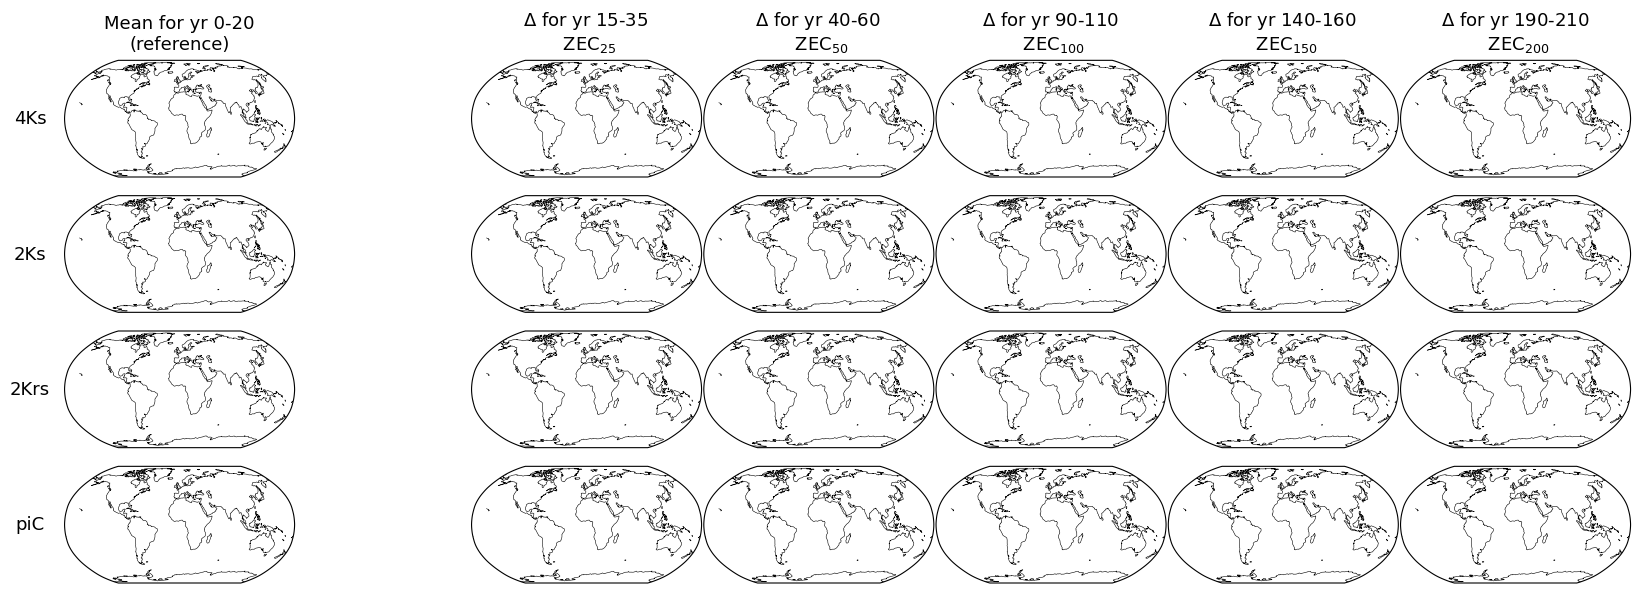

In [20]:
fig, axs = create_4x6_robinson_figure()

plt.show()

## Load in some model data 

In [21]:
def get_cstats(varia):

    if varia == 'tas':

        ref_units = ['K','deg K']
        
        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 220
        vmax_ref = 310
        cmap_ref = plt.get_cmap('cmo.thermal',18)

        vmin_anom = -3.5
        vmax_anom = 3.5
        cmap_anom = plt.get_cmap('cmo.balance',35)


    elif varia == 'tos':

        ref_units = ['°C','degC', 'deg C']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
    
        vmin_ref = -2
        vmax_ref = 32
        cmap_ref = plt.get_cmap('cmo.thermal',17)

        vmin_anom = -2
        vmax_anom = 2
        cmap_anom = plt.get_cmap('cmo.balance',20)

    elif varia == 'nbp':

        ref_units = ['kg\nm-2\ns-1','kg/m2/s', 'kgC/m2/s']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = -2e-9
        vmax_ref = 2e-9
        cmap_ref = plt.get_cmap('cmo.balance_r',16)

        vmin_anom = -2e-9
        vmax_anom = 2e-9
        cmap_anom = plt.get_cmap('cmo.balance_r',16)

    elif varia == 'fgco2':

        ref_units = ['kg\nm-2\ns-1','kg/m2/s', 'kgC/m2/s']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = -2e-9
        vmax_ref = 2e-9
        cmap_ref = plt.get_cmap('cmo.balance_r',16)

        vmin_anom = -2e-9
        vmax_anom = 2e-9
        cmap_anom = plt.get_cmap('cmo.balance_r',16)

    elif varia == 'intpp':

        ref_units = ['mol\nm-2\ns-1','mol/m2/s']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 1e-6
        cmap_ref = plt.get_cmap('cmo.rain',18)

        vmin_anom = -1e-7
        vmax_anom = 1e-7
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    elif varia == 'npp':

        ref_units = ['kg\nm-2\ns-1','kg/m2/s','kgC/m2/s']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 4e-8
        cmap_ref = plt.get_cmap('cmo.rain',16)

        vmin_anom = -4e-9
        vmax_anom = 4e-9
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    elif varia == 'cLand':

        ref_units = ['kg m-2','kg/m2']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 50
        cmap_ref = plt.get_cmap('cmo.rain',25)

        vmin_anom = -5
        vmax_anom = 5
        cmap_anom = plt.get_cmap('cmo.curl_r',30)

    elif varia == 'cSoil':

        ref_units = ['kg m-2','kg/m2']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 50
        cmap_ref = plt.get_cmap('cmo.rain',18)

        vmin_anom = -5
        vmax_anom = 5
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    elif varia == 'cVeg':

        ref_units = ['kg m-2','kg/m2']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 50
        cmap_ref = plt.get_cmap('cmo.rain',18)

        vmin_anom = -5
        vmax_anom = 5
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    elif varia == 'dissic':

        ref_units = ['kg m-2','kg/m2']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 200
        cmap_ref = plt.get_cmap('cmo.ice_r',20)

        vmin_anom = -7
        vmax_anom = 7
        cmap_anom = plt.get_cmap('cmo.balance_r',28)

    elif varia == 'intdic':

        ref_units = ['kg m-2','kg/m2']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 200
        cmap_ref = plt.get_cmap('cmo.ice_r',20)

        vmin_anom = -7
        vmax_anom = 7
        cmap_anom = plt.get_cmap('cmo.balance_r',28)
    
    
    cstats = dict()
    cstats['plot_anoms'] = plot_anoms
    cstats['vmin_ref'] = vmin_ref
    cstats['vmax_ref'] = vmax_ref
    cstats['cmap_ref'] = cmap_ref
    cstats['plot_agreement_ref'] = plot_agreement_ref  

    #if plot_anoms == True:
    cstats['vmin_anom'] = vmin_anom
    cstats['vmax_anom'] = vmax_anom
    cstats['cmap_anom'] = cmap_anom  
    cstats['plot_agreement_anom'] = plot_agreement_anom

    return cstats, ref_units
    

In [22]:
def get_mask(varia,model):
    with xr.open_dataset(f'./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/tos/{model}/mean/tos_{model}_mean_win21yr.nc') as mask_ds:
        maskdumds = mask_ds['esm-up2p0-gwl2p0'].isel(ZEC=0).squeeze()
        ocean_mask = xr.where(np.isnan(maskdumds),np.NaN,1).load()
        land_mask = xr.where(np.isnan(maskdumds),1,np.NaN).load()
        atmosphere_mask = xr.where(maskdumds==1e20,np.NaN,1).load()
        if varia in ['nbp','npp','cLand','cSoil','cVeg']:
            mask = land_mask
        elif varia in ['tos','fgco2','intpp','dissic','intdic']:
            mask = ocean_mask
        elif varia in ['tas']:
            mask = atmosphere_mask
        else:
            raise Exception('Mask not yet implemented for this variable')
    return mask

[[1850 1850 1865 1890 1940 1990 2040]
 [1951 1951 1966 1991 2041 2091 2141]
 [2057 2057 2072 2097 2147 2197 2247]
 [2185 2185 2200 2225 2275 2325 2375]]
[[1850 1870 1885 1910 1960 2010 2060]
 [1951 1971 1986 2011 2061 2111 2161]
 [2057 2077 2092 2117 2167 2217 2267]
 [2185 2205 2220 2245 2295 2345 2395]]


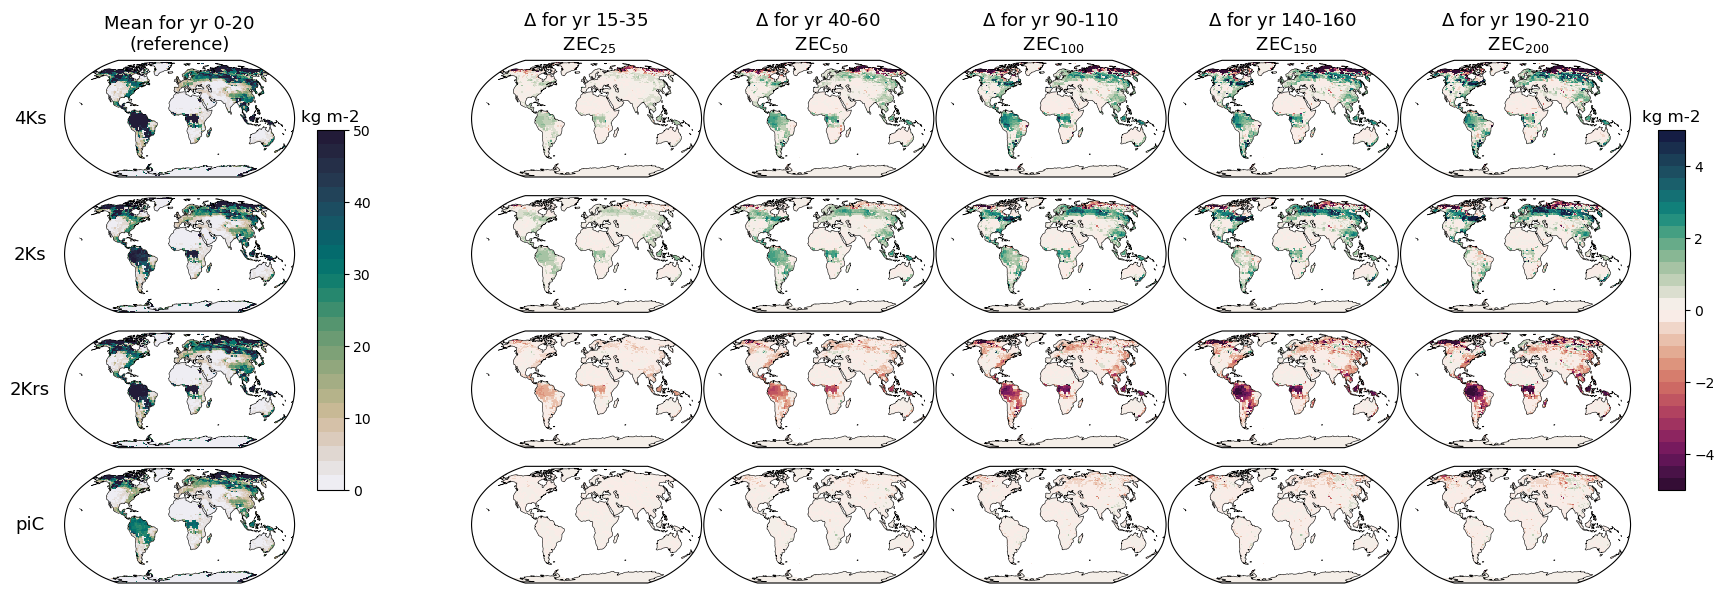

[[1861 1861 1876 1901 1951 2001 2051]
 [1958 1958 1973 1998 2048 2098 2148]
 [2064 2064 2079 2104 2154 2204 2254]
 [2240 2240 2255 2280 2330 2380 2430]]
[[1861 1881 1896 1921 1971 2021 2071]
 [1958 1978 1993 2018 2068 2118 2168]
 [2064 2084 2099 2124 2174 2224 2274]
 [2240 2260 2275 2300 2350 2400 2450]]


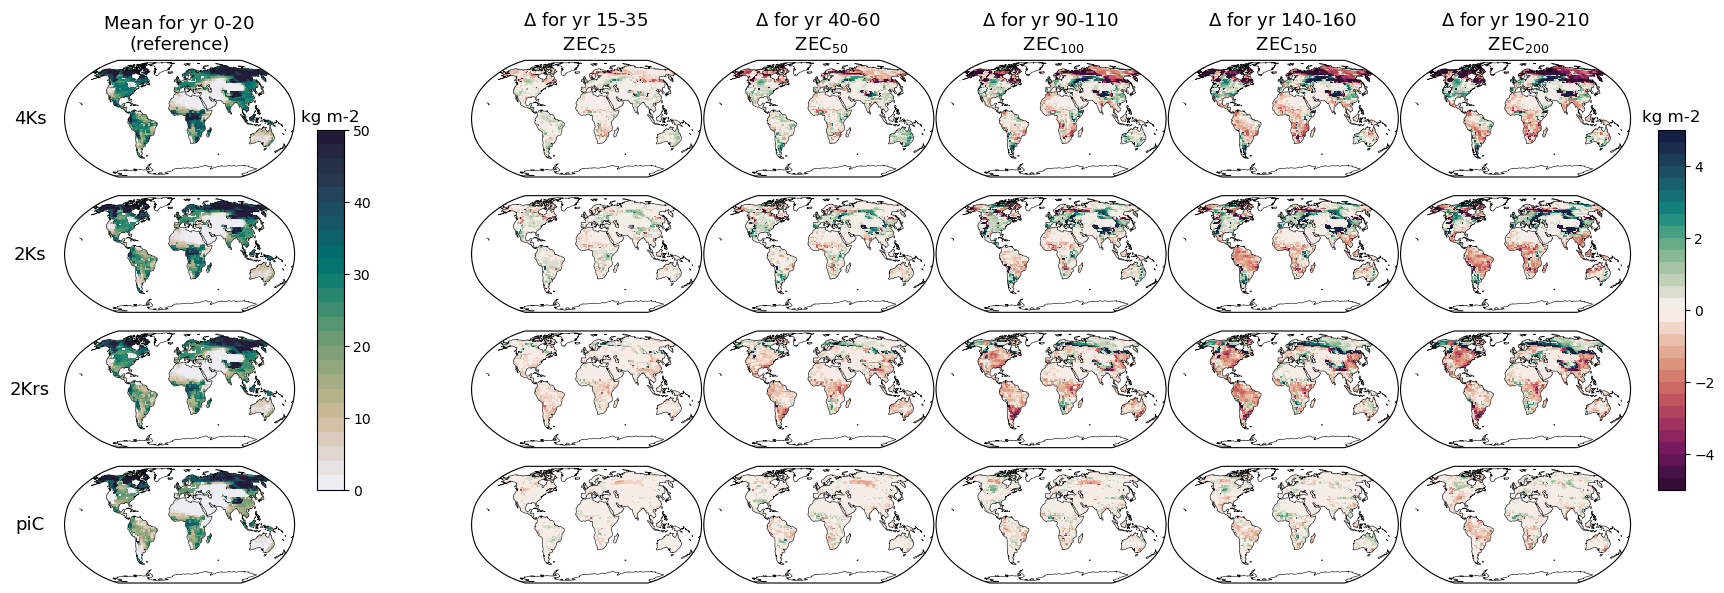

[[1850 1850 1865 1890 1940 1990 2040]
 [1959 1959 1974 1999 2049 2099 2149]
 [2082 2082 2097 2122 2172 2222 2272]
 [2232 2232 2247 2272 2322 2372 2422]]
[[1850 1870 1885 1910 1960 2010 2060]
 [1959 1979 1994 2019 2069 2119 2169]
 [2082 2102 2117 2142 2192 2242 2292]
 [2232 2252 2267 2292 2342 2392 2442]]


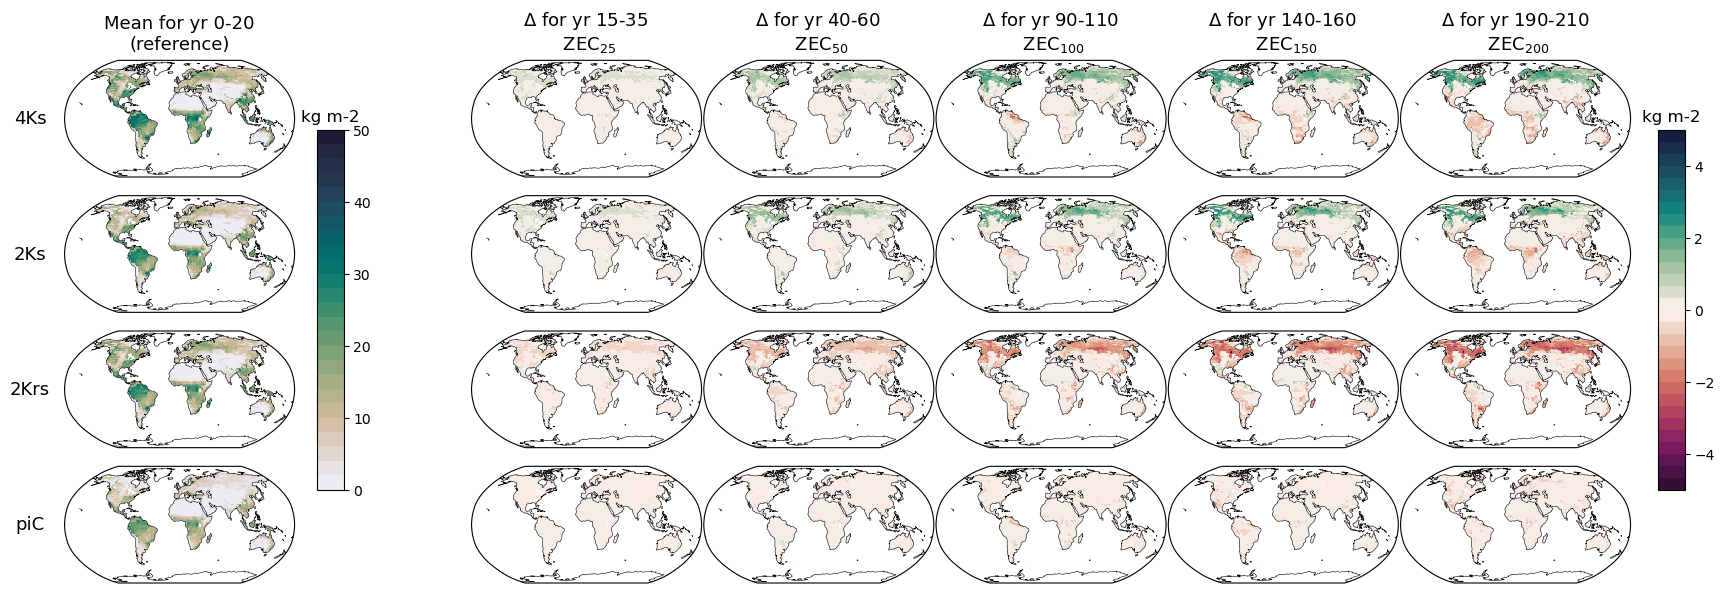

In [99]:
models = ['NorESM2-LM','GFDL-ESM2M','IPSL-CM6-ESMCO2']
varias = ['cLand']#['cSoil']#['fgco2','nbp']#['intpp','npp']#['tas']#['tos']   #['intpp','npp']#['tas']#['fgco2','nbp']#['tos']#['tos'] #['tas']#['fgco2','nbp']#

temporal_stats = ['mean']#,'linear_trend']

ZECs = [25,50,100,150,200]
ref_zec = 10
runs = ['esm-up2p0-gwl4p0','esm-up2p0-gwl2p0','esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0','esm-piControl']

cbax_xlocs = [0.915,0.96]
cbax_ref_xlocs = [0.17,0.215]

for model in models:

    for temporal_stat in temporal_stats:
        
        fig, ax = create_4x6_robinson_figure()

        for vdx,varia in enumerate(varias):
            cstats, ref_units = get_cstats(varia)

            # get the data
            if temporal_stat == 'mean':
                window_size = 21
                dps = f'./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/{varia}/{model}/{temporal_stat}/{varia}_{model}_{temporal_stat}_win{window_size}yr.nc'
            elif temporal_stat == 'linear_trend':
                dps = f'./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/{varia}/{model}/{temporal_stat}/{varia}_{model}_{temporal_stat}.nc'

            # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
            # use a random file to define the ocean and land and atmosphere mask
            mask = get_mask(varia,model)

            with xr.open_dataset(dps) as dumds:
                print(dumds.ZEC_start_year.values)
                print(dumds.ZEC_end_year.values)
    
                ZEC_ds = dumds.sel(ZEC=ZECs).load()
                if temporal_stat == 'mean':
                    ref_ds = dumds.sel(ZEC=ref_zec).load()
            
            for rdx,run in enumerate(runs):

                data_to_plot = ref_ds[run].squeeze() * mask
                vmin = cstats['vmin_ref']
                vmax = cstats['vmax_ref']
                cmap = cstats['cmap_ref']
                c_ref = ax[rdx,0].pcolormesh(data_to_plot.lon,data_to_plot.lat,data_to_plot,vmin=vmin,vmax=vmax,cmap=cmap,transform=ccrs.PlateCarree()) # plot relative to first year of run
                
                for zdx,ZEC in enumerate(ZECs):
                    if temporal_stat == 'mean':
                        if cstats['plot_anoms'] == True:
                            vmin = cstats['vmin_anom']
                            vmax = cstats['vmax_anom']
                            cmap = cstats['cmap_anom']
                            data_to_plot = (ZEC_ds[run].sel(ZEC=ZEC) - ref_ds[run]).squeeze()  * mask
                        else:
                            vmin = cstats['vmin_ref']
                            vmax = cstats['vmax_ref']
                            cmap = cstats['cmap_ref']                            
                            data_to_plot = (ZEC_ds[run].sel(ZEC=ZEC)).squeeze()
                        c0 = ax[rdx,zdx+1].pcolormesh(data_to_plot.lon,data_to_plot.lat,data_to_plot,vmin=vmin,vmax=vmax,cmap=cmap,transform=ccrs.PlateCarree()) # plot relative to first year of run
                    elif temporal_stat == 'linear_trend':
                        vmin = cstats['vmin_anom']
                        vmax = cstats['vmax_anom']
                        cmap = cstats['cmap_anom']
                        data_to_plot = ZEC_ds[run].sel(ZEC=ZEC).squeeze() * ZEC  * mask
                        c0 = ax[rdx,zdx+1].pcolormesh(data_to_plot.lon,data_to_plot.lat,data_to_plot,vmin=vmin,vmax=vmax,cmap=cmap,transform=ccrs.PlateCarree()) # plot relative to first year of run

            try:
                dumds.close()
            except:
                print('already closed')
                
            # One colorbar for all panels
            cbax = fig.add_axes([cbax_xlocs[vdx],0.2,0.015,0.6])
            cbar = fig.colorbar(
                c0,
                cax=cbax,
                #location="right",
                #shrink=0.6,
                #pad=0.02,
                #aspect=35,
            )
            cbax_ref = fig.add_axes([cbax_ref_xlocs[vdx],0.2,0.015,0.6])
            cbar_ref = fig.colorbar(
                c_ref,
                cax=cbax_ref,
                #location="right",
                #shrink=0.6,
                #pad=0.02,
                #aspect=35,
            )
            
            cbar.ax.set_title(f"{ref_units[0]}")   
            cbar_ref.ax.set_title(f"{ref_units[0]}")   

        varia_string = '_'.join(varias)
        os.makedirs(f'../03_plots/global_time_slice_maps_ZEC/{varia_string}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/',exist_ok=True)
        plt.savefig(f'../03_plots/global_time_slice_maps_ZEC/{varia_string}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/fig_ZEC_{varia_string}_{model}_{temporal_stat}.png')
        plt.show()

## Now make the same plot but in a multi model sense (hatching indicating where less than 80% of models agree on the sign

In [100]:
# first reorganize the data

for temporal_stat in temporal_stats:
    all_models = dict()

    for vdx, varia in enumerate(varias):
        all_models_dum = []

        for model in models:
            if temporal_stat == 'mean':
                window_size = 21
                dps = f'./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/{varia}/{model}/{temporal_stat}/{varia}_{model}_{temporal_stat}_win{window_size}yr.nc'
            elif temporal_stat == 'linear_trend':
                dps = f'./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/{varia}/{model}/{temporal_stat}/{varia}_{model}_{temporal_stat}.nc'

            with xr.open_dataset(dps) as ds:
                all_models_dum.append(ds.load())

        all_models[varia] = xr.concat(
            all_models_dum,
            dim=xr.DataArray(
                range(len(all_models_dum)),
                dims="model",
                coords={"model": models},
                name="ref",
            ),
            coords='minimal'
        )
        # close the individual files
        #for dsi in all_models_dum:
        #    dsi.close()


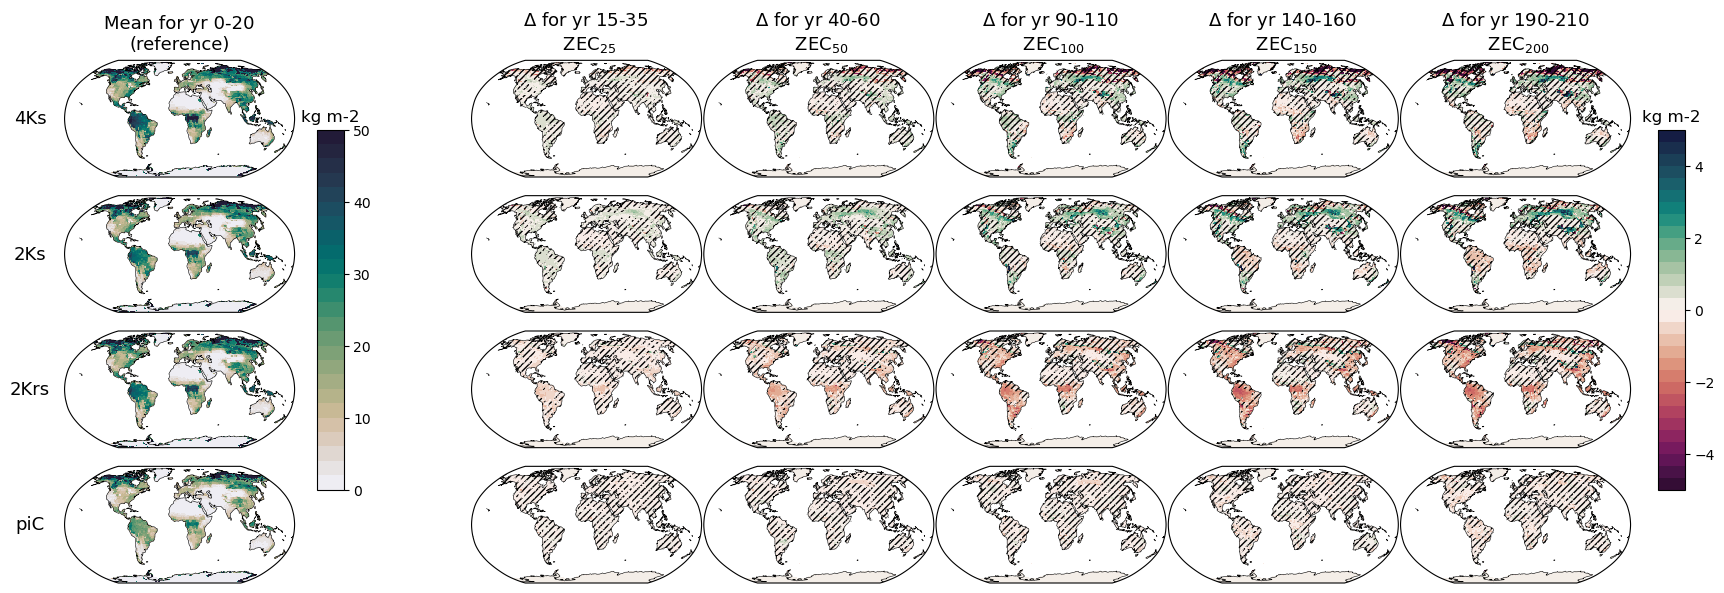

In [101]:
def sign_agreement(da: xr.DataArray, dim: str) -> xr.DataArray:
    """Percentage of values sharing the majority sign along `dim`."""
    n_pos = (da > 0).sum(dim)
    n_neg = (da < 0).sum(dim)
    n = n_pos + n_neg

    return xr.where(
        n > 0,
        np.maximum(n_pos, n_neg) / n,
        np.nan,
    )

# now plot
ZEC_sel = [25,50,100,150,200]
for temporal_stat in temporal_stats:
    
    fig, ax = create_4x6_robinson_figure()
    for vdx,varia in enumerate(varias):
        cstats, ref_units = get_cstats(varia)

        # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
        # use a random file to define the ocean and land and atmosphere mask
        mask = get_mask(varia,models[0])

        for rdx,run in enumerate(runs):
            allmodda = all_models[varia][run]

            # first plot the MMM of the reference fields
            vmin = cstats['vmin_ref']
            vmax = cstats['vmax_ref']
            cmap = cstats['cmap_ref']
            
            ref_mean = allmodda.sel(ZEC=ref_zec).mean(dim='model') * mask
            # compute ref agreement
            ref_agreement = sign_agreement(allmodda.sel(ZEC=ref_zec), dim="model")
            
            c_ref = ax[rdx,0].pcolormesh(ref_mean.lon,ref_mean.lat,ref_mean,vmin=vmin,vmax=vmax,cmap=cmap,transform=ccrs.PlateCarree()) # plot relative to first year of run
            ax[rdx,0].contourf(ref_agreement.lon,ref_agreement.lat,ref_agreement < 0.8,levels=[0.5, 1.5],hatches=["/////"],colors="none",transform=ccrs.PlateCarree())
            
            # now plot the zero emission commitment
            for zdx,ZEC in enumerate(ZEC_sel):
                if temporal_stat == 'mean':
                    if cstats['plot_anoms'] == True:
                        vmin = cstats['vmin_anom']
                        vmax = cstats['vmax_anom']
                        cmap = cstats['cmap_anom']
                        mmm_val = (allmodda.sel(ZEC=ZEC) - allmodda.sel(ZEC=ref_zec)).mean(dim='model') * mask 
                        zec_agreement = sign_agreement(allmodda.sel(ZEC=ZEC) - allmodda.sel(ZEC=ref_zec), dim="model")
                    else:
                        vmin = cstats['vmin_ref']
                        vmax = cstats['vmax_ref']
                        cmap = cstats['cmap_ref'] 
                        mmm_val = allmodda.sel(ZEC=ZEC).mean(dim='model') * mask
                        zec_agreement = sign_agreement(allmodda.sel(ZEC=ZEC), dim="model")
                    c0 = ax[rdx,zdx+1].pcolormesh(mmm_val.lon,mmm_val.lat,mmm_val,vmin=vmin,vmax=vmax,cmap=cmap,transform=ccrs.PlateCarree()) # plot relative to first year of run
                    ax[rdx,zdx+1].contourf(zec_agreement.lon,zec_agreement.lat,zec_agreement < 0.8,levels=[0.5, 1.5],hatches=["/////"],colors="none",transform=ccrs.PlateCarree())
                elif temporal_stat == 'linear_trend':
                    vmin = cstats['vmin_anom']
                    vmax = cstats['vmax_anom']
                    cmap = cstats['cmap_anom']
                    mmm_val = (allmodda.sel(ZEC=ZEC)*ZEC).mean(dim='model') * mask
                    zec_agreement = sign_agreement(allmodda.sel(ZEC=ZEC)*ZEC, dim="model")
                    c0 = ax[rdx,zdx+1].pcolormesh(mmm_val.lon,mmm_val.lat,mmm_val,vmin=vmin,vmax=vmax,cmap=cmap,transform=ccrs.PlateCarree()) # plot relative to first year of run
                    ax[rdx,zdx+1].contourf(zec_agreement.lon,zec_agreement.lat,zec_agreement < 0.8,levels=[0.5, 1.5],hatches=["/////"],colors="none",transform=ccrs.PlateCarree())

        # One colorbar for all panels
        cbax = fig.add_axes([cbax_xlocs[vdx],0.2,0.015,0.6])
        cbar = fig.colorbar(
            c0,
            cax=cbax,
            #location="right",
            #shrink=0.6,
            #pad=0.02,
            #aspect=35,
        )
        cbax_ref = fig.add_axes([cbax_ref_xlocs[vdx],0.2,0.015,0.6])
        cbar_ref = fig.colorbar(
            c_ref,
            cax=cbax_ref,
            #location="right",
            #shrink=0.6,
            #pad=0.02,
            #aspect=35,
        )
        
        cbar.ax.set_title(f"{ref_units[0]}")   
        cbar_ref.ax.set_title(f"{ref_units[0]}")   

    varia_string = '_'.join(varias)
    os.makedirs(f'../03_plots/global_time_slice_maps_ZEC/{varia_string}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/',exist_ok=True)
    plt.savefig(f'../03_plots/global_time_slice_maps_ZEC/{varia_string}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/fig_ZEC_{varia_string}_MMM_{temporal_stat}.png')
    plt.show()

## Now compute spatial means

In [102]:
def get_area1x1():
    
    # Grid centers
    lat = np.arange(-89.5, 90.5, 1.0)
    lon = np.arange(-179.5, 180.5, 1.0)
    
    # Earth radius (m)
    R = 6_371_000.0
    
    # Cell boundaries
    lat_bnds = np.deg2rad(np.arange(-90, 91, 1.0))
    dlon = np.deg2rad(1.0)
    
    # Cell areas (latitude only)
    area_lat = (
        R**2
        * dlon
        * (np.sin(lat_bnds[1:]) - np.sin(lat_bnds[:-1]))
    )
    
    # Broadcast to 2D
    area = xr.DataArray(
        np.repeat(area_lat[:, None], len(lon), axis=1),
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="cell_area",
        attrs={
            "units": "m2",
            "long_name": "Grid cell area",
        },
    )

    return area

area1x1 = get_area1x1()
print('done')

done


In [103]:
def get_global_stat(varia):
    if varia in ['tas','tos']:
        global_stat = 'mean'
    else:
        global_stat = 'integral'
    return global_stat

In [104]:
print('here')
global_stats = dict()
for model in models:
    global_stats[model] = dict()
    for temporal_stat in temporal_stats:
        global_stats[model][temporal_stat] = dict()
        for vdx,varia in enumerate(varias):
            global_stat = get_global_stat(varia)
            cstats, ref_units = get_cstats(varia)

            #print(f'{model}, {varia}, until here')
            # get the data
            if temporal_stat == 'mean':
                dps = f'./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/{varia}/{model}/{temporal_stat}/{varia}_{model}_{temporal_stat}_win21yr.nc'
            elif temporal_stat == 'linear_trend':
                dps = f'./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/{varia}/{model}/{temporal_stat}/{varia}_{model}_{temporal_stat}.nc'
            print(dps)

            mask = get_mask(varia,model)
            with xr.open_dataset(dps) as dumds:
                #print('calc global integral for ...')
                #print(varia)
                #print(f'{model}, {varia}, until here 2')
                # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
                # use a random file to define the ocean and land and atmosphere mask

                #print(f'{model}, {varia}, until here 3')
                if global_stat == 'mean':
                    global_stats[model][temporal_stat][varia] = SpaceOperator.calc_spatial_mean(dumds*mask,area1x1).load()#.weighted(area1x1).mean(dim=('lat','lon')).compute()
                elif global_stat == 'integral':
                    global_stats[model][temporal_stat][varia] = SpaceOperator.calc_spatial_integral(dumds*mask,area1x1).load()#.weighted(area1x1).mean(dim=('lat','lon')).compute()



here
./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/cLand/NorESM2-LM/mean/cLand_NorESM2-LM_mean_win21yr.nc
./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/cLand/GFDL-ESM2M/mean/cLand_GFDL-ESM2M_mean_win21yr.nc
./../01_postprocessed_data/global_time_slice_statistic_maps_ZEC/cLand/IPSL-CM6-ESMCO2/mean/cLand_IPSL-CM6-ESMCO2_mean_win21yr.nc


## Plot global means as line plots

In [105]:
run_dict = pruns.get_run_dict()
model_dict = pmods.get_model_dict()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


kg m-2
kg m-2
kg m-2
kg m-2


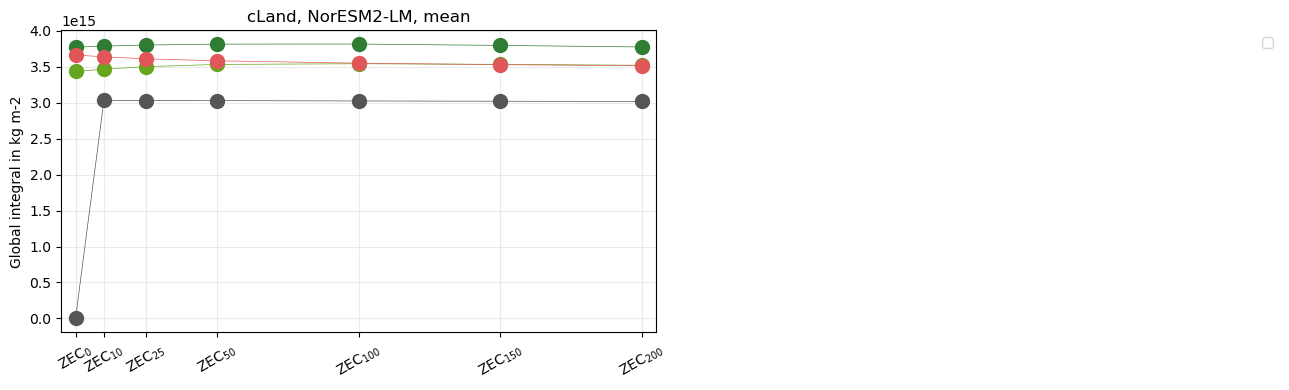

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


kg m-2
kg m-2
kg m-2
kg m-2


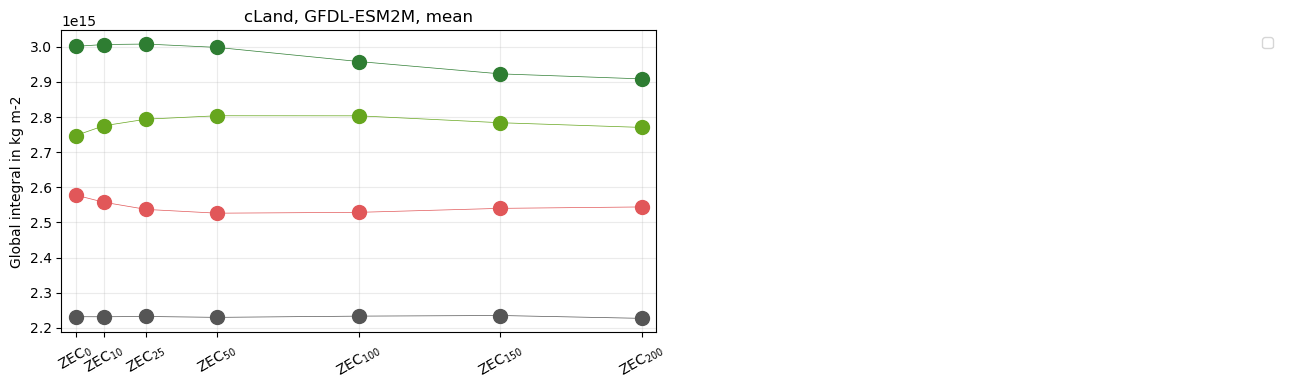

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


kg m-2
kg m-2
kg m-2
kg m-2


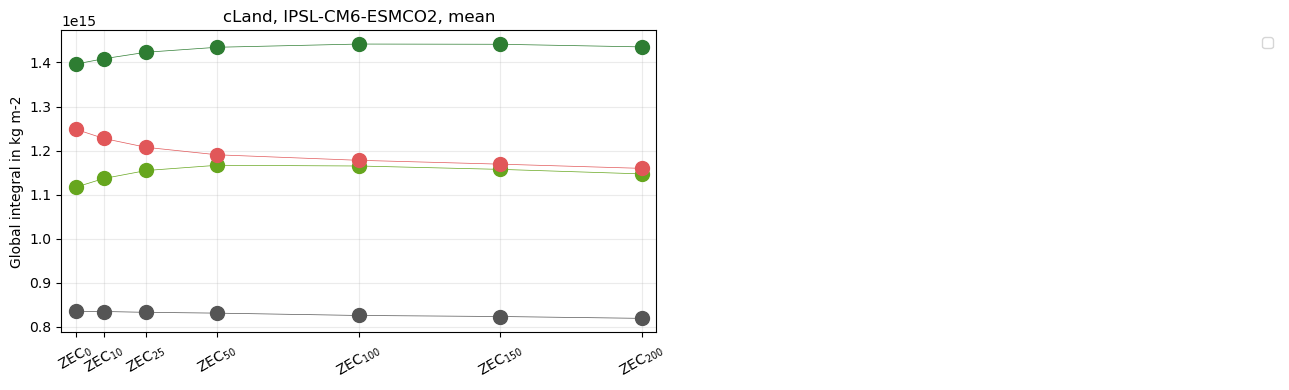

In [106]:
def get_converter(ref_unit):
    print(ref_unit)
    if ref_unit == 'kg\nm-2\ns-1':
        conversion_fac = 1/1000/1000/1000/1000*60*60*24*365.25
        new_unit = 'PgC yr-1'
    elif ref_unit == 'mol\nm-2\ns-1':
        conversion_fac = 12/1000/1000/1000/1000/1000*60*60*24*365.25
        new_unit = 'PgC yr-1'
    else:
        conversion_fac = 1
        new_unit = ref_unit
    return conversion_fac, new_unit

ZEC_sel = [0,10,25,50,100,150,200]
for model in models:
    for temporal_stat in temporal_stats:
        if varias == ['fgco2','nbp']:
            sharey=True
        else:
            sharey=False
        fig, ax = plt.subplots(1,2,figsize=(13,4),sharex='col',sharey=sharey)#,sharey='col')
        if len(varias)==1:
            ax[1].set_axis_off()
        for vdx,varia in enumerate(varias):
            global_stat = get_global_stat(varia)
            for rdx,run in enumerate(runs):
                    
                data = global_stats[model][temporal_stat][varia][run] #.sel(ZEC=ZEC_sel)
                data_sel = data.sel(ZEC=ZEC_sel)
        
                cstats, ref_units = get_cstats(varia)
                conversion_fac, new_unit = get_converter(ref_units[0])
                
                if temporal_stat == 'linear_trend':
                    ax[vdx].plot(data_sel.ZEC,data_sel,label=run,marker='o',linewidth=0.5,markersize=10) # *ds.ZEC
                    ax[vdx].set_ylabel(f'Global mean linear trend in {ref_units[0]} yr-1'.replace('\n',' ')) # *ZEC_period
                    plt.axhline(0,linestyle='--',color='k')
                elif temporal_stat == 'linear_change':
                    ax[vdx].plot(data_sel.ZEC,data_sel*ZEC_sel,label=run,marker='o',linewidth=0.5,markersize=10) # *ds.ZEC
                    ax[vdx].set_ylabel(f'Global mean linear change in {ref_units[0]}'.replace('\n',' ')) # *ZEC_period
                    plt.axhline(0,linestyle='--',color='k')
                elif temporal_stat == 'mean':
                    ax[vdx].plot(data_sel.ZEC,data_sel*conversion_fac,label=run,marker='o',linewidth=0.5,markersize=10,color=run_dict[run].color_id) # -ds_global_mean[run].sel(ZEC=10)
                    if vdx == 0:
                        if varia in ['tas','tos']:
                            ax[vdx].set_ylabel(f'Global {global_stat} in {f"{new_unit}"}'.replace('\n',' '))
                        else:
                            ax[vdx].set_ylabel(f'Global {global_stat} in {f"{new_unit}"}'.replace('\n',' '))
            ax[vdx].set_xticks(data_sel.ZEC)
            ax[vdx].set_xticklabels([f'ZEC$_{{{zec_value}}}$' for zec_value in data_sel.ZEC.values],rotation=30)
            ax[vdx].set_xlim([-5,205])
            ax[vdx].grid(alpha=0.25)
            ax[vdx].set_title(f'{varia}, {model}, {temporal_stat}')
            if varia in ['nbp','fgco2']:
                ax[vdx].axhline(0,zorder=-1,ls='--',color='k',linewidth=0.75)
        ax[1].legend()
        plt.tight_layout()
        #plt.savefig(f'fig_ZEC_{varia_string}_{model}_{temporal_stat}_global_integral_lineplot.png')    
        plt.savefig(f'../03_plots/global_time_slice_maps_ZEC/{varia_string}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/fig_ZEC_{varia_string}_{model}_{temporal_stat}_global_{global_stat}_lineplot.png')
    
        plt.show()

## Now plot things in a multimodel sense

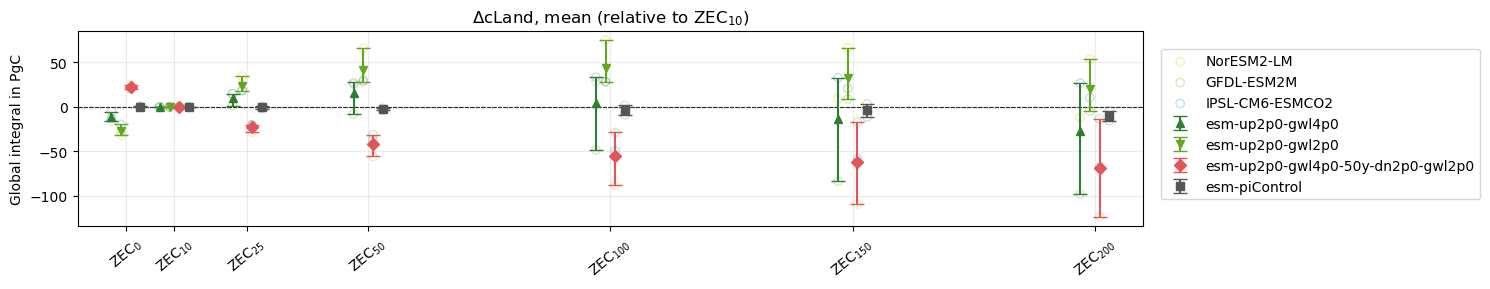

In [107]:
def get_converter(ref_unit,global_stat='integral'):
    #print(ref_unit)
    if ref_unit == 'kg\nm-2\ns-1':
        conversion_fac = 1/1000/1000/1000/1000*60*60*24*365.25
        new_unit = 'PgC yr-1'
    elif ref_unit == 'mol\nm-2\ns-1':
        conversion_fac = 12/1000/1000/1000/1000/1000*60*60*24*365.25
        new_unit = 'PgC yr-1'
    elif ref_unit == 'kg m-2' and global_stat == 'integral':
        conversion_fac = 1/1000/1000/1000/1000
        new_unit = 'PgC'
    else:
        conversion_fac = 1
        new_unit = ref_unit
    return conversion_fac, new_unit

ZEC_sel = [0,10,25,50,100,150,200]#,250,300]

if varias == ['fgco2','nbp']:
    sharey=True
else:
    sharey=False

for varia in varias:
    fig, ax = plt.subplots(1,1,figsize=(15,3))#,sharex='col'),sharey=sharey)#,sharey='col')
    #if len(varias)==1:
    ax = [ax]
    for temporal_stat in temporal_stats:
        vdx = 0
        global_stat = get_global_stat(varia)

        offset_list = (np.arange(len(runs))-(len(runs)-1)/2)*2
        for rdx,run in enumerate(runs):

            for ZECo in ZEC_sel:
                agg_list = []
                agg_dict = dict()

                for model in models:

                    if model == 'NorESM2-LM' and run == 'esm-piControl':
                        continue
                        
                    data = global_stats[model][temporal_stat][varia][run] #.sel(ZEC=ZEC_sel)
                    data_sel = data.sel(ZEC=ZECo) - data.sel(ZEC=10)
            
                    cstats, ref_units = get_cstats(varia)
                    conversion_fac, new_unit = get_converter(ref_units[0])
    
                    data_sel = data_sel * conversion_fac

                    agg_list.append(data_sel)
                    agg_dict[model] = data_sel


                data = np.array(agg_list)
                mean = data.mean()
                yerr = [[mean - data.min()],    # lower whisker
                        [data.max() - mean]]    # upper whisker

                if ZECo == 25:
                    label = run
                else:
                    label = ''
                ax[vdx].errorbar(
                    ZECo+offset_list[rdx], mean,
                    yerr=yerr,
                    fmt=run_dict[run].marker_id,
                    capsize=5,
                    color=run_dict[run].color_id,
                    label=label,
                )

                for model in models:
                    
                    if model == 'NorESM2-LM' and run == 'esm-piControl':
                        continue
                    
                    if ZECo == 25 and run == 'esm-up2p0-gwl2p0':
                        label = model
                    else:
                        label = ''
                    ax[vdx].scatter(
                        ZECo+offset_list[rdx], agg_dict[model],
                        marker = 'o',
                        facecolor='none',
                        color=model_dict[model].color_id,
                        label=label,
                        alpha=0.25
                    )                
            
            if vdx == 0:
                if varia in ['tas','tos']:
                    ax[vdx].set_ylabel(f'Global {global_stat} in {f"{new_unit}"}'.replace('\n',' '))
                else:
                    ax[vdx].set_ylabel(f'Global {global_stat} in {f"{new_unit}"}'.replace('\n',' '))
            ax[vdx].set_xticks(ZEC_sel)
            ax[vdx].set_xticklabels([f'ZEC$_{{{zec_value}}}$' for zec_value in ZEC_sel],rotation=40)
            ax[vdx].set_xlim([-10,210])
            #ax[vdx].set_xscale('log')
            ax[vdx].grid(alpha=0.25)
            ax[vdx].set_title(f'$\Delta${varia}, {temporal_stat} (relative to ZEC$_{{{10}}}$)')
            #ax[vdx].set_title(f'{varia}, {temporal_stat}')
            #if varia in ['nbp','fgco2']:
            ax[vdx].axhline(0,zorder=-1,ls='--',color='k',linewidth=0.75)
            ax[0].legend(loc='lower left',bbox_to_anchor=(1.01,0.1))
            plt.tight_layout()
            os.makedirs(f'../03_plots/global_time_slice_maps_ZEC/{varia}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/',exist_ok=True)
            #plt.savefig(f'fig_ZEC_{varia_string}_{model}_{temporal_stat}_global_integral_lineplot.png')    
            plt.savefig(f'../03_plots/global_time_slice_maps_ZEC/{varia}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/fig_ZEC_{varia}_MM_{temporal_stat}_global_{global_stat}_boxplot.png')
        
    plt.show()

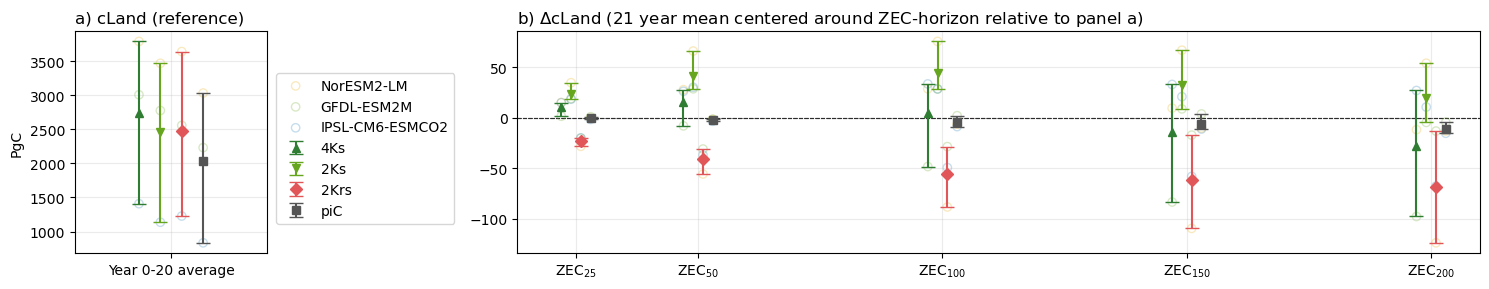

In [108]:
def get_converter(ref_unit,global_stat='integral'):
    #print(ref_unit)
    if ref_unit == 'kg\nm-2\ns-1':
        conversion_fac = 1/1000/1000/1000/1000*60*60*24*365.25
        new_unit = 'PgC yr-1'
    elif ref_unit == 'mol\nm-2\ns-1':
        conversion_fac = 12/1000/1000/1000/1000/1000*60*60*24*365.25
        new_unit = 'PgC yr-1'
    elif ref_unit == 'kg m-2' and global_stat == 'integral':
        conversion_fac = 1/1000/1000/1000/1000
        new_unit = 'PgC'
    else:
        conversion_fac = 1
        new_unit = ref_unit
    return conversion_fac, new_unit

ZEC_sel = [10,25,50,100,150,200]#,250,300]

if varias == ['fgco2','nbp']:
    sharey=True
else:
    sharey=False

for varia in varias:
    fig, ax = plt.subplots(1,2,figsize=(15,3),gridspec_kw={'width_ratios': [1, 5]})#,sharex='col'),sharey=sharey)#,sharey='col')
    #if len(varias)==1:
    #ax = [ax]
    for temporal_stat in temporal_stats:
        global_stat = get_global_stat(varia)

        offset_list = (np.arange(len(runs))-(len(runs)-1)/2)*2

        for rdx,run in enumerate(runs):
            for ZECo in ZEC_sel:

                agg_list = []
                agg_dict = dict()

                for model in models:

                    #if model == 'NorESM2-LM' and run == 'esm-piControl':
                    #    continue

                    data = global_stats[model][temporal_stat][varia][run] #.sel(ZEC=ZEC_sel)
                    if ZECo == 10:
                        data_sel = data.sel(ZEC=10)
                        vdx = 0
                    else:
                        data_sel = data.sel(ZEC=ZECo) - data.sel(ZEC=10)
                        vdx = 1
            
                    cstats, ref_units = get_cstats(varia)
                    conversion_fac, new_unit = get_converter(ref_units[0])
    
                    data_sel = data_sel * conversion_fac

                    agg_list.append(data_sel)
                    agg_dict[model] = data_sel


                data = np.array(agg_list)
                mean = data.mean()
                yerr = [[mean - data.min()],    # lower whisker
                        [data.max() - mean]]    # upper whisker

                if ZECo == 10:
                    if run == 'esm-piControl':
                        label = 'piC'
                    elif run == 'esm-up2p0-gwl2p0':
                        label = '2Ks'
                    elif run == 'esm-up2p0-gwl4p0':
                        label = '4Ks'
                    elif run == 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0':
                        label = '2Krs'
                else:
                    label = ''
                ax[vdx].errorbar(
                    ZECo+offset_list[rdx], mean,
                    yerr=yerr,
                    fmt=run_dict[run].marker_id,
                    capsize=5,
                    color=run_dict[run].color_id,
                    label=label,
                )

                for model in models:
                    
                    #if model == 'NorESM2-LM' and run == 'esm-piControl':
                    #    continue
                    
                    if ZECo == 10 and run == 'esm-up2p0-gwl2p0':
                        label = model
                    else:
                        label = ''
                    ax[vdx].scatter(
                        ZECo+offset_list[rdx], agg_dict[model],
                        marker = 'o',
                        facecolor='none',
                        color=model_dict[model].color_id,
                        label=label,
                        alpha=0.25
                    )                
            
            #if vdx == 0:
            for vdx in [0]:#,1]:
                if varia in ['tas','tos']:
                    ax[vdx].set_ylabel(f'{f"{new_unit}"}'.replace('\n',' ')) # Global {global_stat} in 
                else:
                    ax[vdx].set_ylabel(f'{f"{new_unit}"}'.replace('\n',' ')) # Global {global_stat} in 
            for vdx in [0,1]:
                ax[vdx].grid(alpha=0.25)
                if vdx == 0:
                    ax[vdx].set_xticks([ZEC_sel[0]])
                    ax[vdx].set_xticklabels([f'Year 0-{window_size-1} average' for zec_value in [ZEC_sel[0]]])
                    ax[vdx].set_xlim([1,19])
                    ax[vdx].set_title(f'a) {varia} (reference)',loc='left')                    
                elif vdx == 1:
                    ax[vdx].set_xticks(ZEC_sel[1:])
                    ax[vdx].set_xticklabels([f'ZEC$_{{{zec_value}}}$' for zec_value in ZEC_sel[1:]],rotation=0)
                    ax[vdx].set_xlim([13,210])
                    ax[vdx].set_title(f'b) $\Delta${varia} ({window_size} year mean centered around ZEC-horizon relative to panel a)',loc='left')
                    #ax[vdx].set_title(f'{varia}, {temporal_stat}')
                    #if varia in ['nbp','fgco2']:
                    ax[vdx].axhline(0,zorder=-1,ls='--',color='k',linewidth=0.75)
            ax[0].legend(loc='lower left',bbox_to_anchor=(1.01,0.1))
            plt.tight_layout()
            os.makedirs(f'../03_plots/global_time_slice_maps_ZEC/{varia}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/',exist_ok=True)
            #plt.savefig(f'fig_ZEC_{varia_string}_{model}_{temporal_stat}_global_integral_lineplot.png')    
            plt.savefig(f'../03_plots/global_time_slice_maps_ZEC/{varia}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/fig_ZEC_{varia}_MM_{temporal_stat}_global_{global_stat}_boxplot.png')
        
    plt.show()

## Older

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


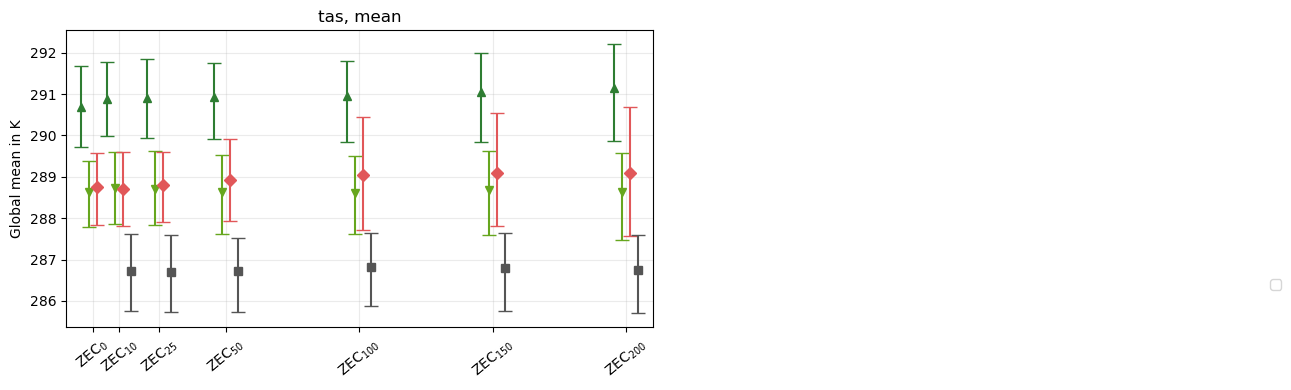

In [11]:
def get_converter(ref_unit):
    #print(ref_unit)
    if ref_unit == 'kg\nm-2\ns-1':
        conversion_fac = 1/1000/1000/1000/1000*60*60*24*365.25
        new_unit = 'PgC yr-1'
    elif ref_unit == 'mol\nm-2\ns-1':
        conversion_fac = 12/1000/1000/1000/1000/1000*60*60*24*365.25
        new_unit = 'PgC yr-1'
    else:
        conversion_fac = 1
        new_unit = ref_unit
    return conversion_fac, new_unit

ZEC_sel = [0,10,25,50,100,150,200]

if varias == ['fgco2','nbp']:
    sharey=True
else:
    sharey=False
    
fig, ax = plt.subplots(1,2,figsize=(13,4),sharex='col',sharey=sharey)#,sharey='col')
if len(varias)==1:
    ax[1].set_axis_off()
for temporal_stat in temporal_stats:
    for vdx,varia in enumerate(varias):
        global_stat = get_global_stat(varia)

        offset_list = (np.arange(len(runs))-(len(runs)-1)/2)*3
        for rdx,run in enumerate(runs):

            for ZECo in ZEC_sel:
                agg_list = []

                for model in models:
    
                    data = global_stats[model][temporal_stat][varia][run] #.sel(ZEC=ZEC_sel)
                    data_sel = data.sel(ZEC=ZECo) #- data.sel(ZEC=0)
            
                    cstats, ref_units = get_cstats(varia)
                    conversion_fac, new_unit = get_converter(ref_units[0])
    
                    data_sel = data_sel * conversion_fac

                    agg_list.append(data_sel)

                data = np.array(agg_list)
                mean = data.mean()
                yerr = [[mean - data.min()],    # lower whisker
                        [data.max() - mean]]    # upper whisker

                if ZECo == 25:
                    label = run
                else:
                    label = ''
                ax[vdx].errorbar(
                    ZECo+offset_list[rdx], mean,
                    yerr=yerr,
                    fmt=run_dict[run].marker_id,
                    capsize=5,
                    color=run_dict[run].color_id,
                    label=label,
                )
            
        if vdx == 0:
            if varia in ['tas','tos']:
                ax[vdx].set_ylabel(f'Global {global_stat} in {f"{new_unit}"}'.replace('\n',' '))
            else:
                ax[vdx].set_ylabel(f'Global {global_stat} in {f"{new_unit}"}'.replace('\n',' '))
        ax[vdx].set_xticks(ZEC_sel)
        ax[vdx].set_xticklabels([f'ZEC$_{{{zec_value}}}$' for zec_value in ZEC_sel],rotation=40)
        ax[vdx].set_xlim([-10,210])
        ax[vdx].grid(alpha=0.25)
        #ax[vdx].set_title(f'$\Delta${varia}, {temporal_stat} (relative to ZEC$_{{{10}}}$)')
        ax[vdx].set_title(f'{varia}, {temporal_stat}')
        if varia in ['nbp','fgco2']:
            ax[vdx].axhline(0,zorder=-1,ls='--',color='k',linewidth=0.75)
        ax[1].legend(loc='lower left',bbox_to_anchor=(1.01,0.1))
        plt.tight_layout()
        #plt.savefig(f'fig_ZEC_{varia_string}_{model}_{temporal_stat}_global_integral_lineplot.png')    
        #plt.savefig(f'../03_plots/global_time_slice_maps_ZEC/{varia_string}/ref_ZEC{ref_zec}_win_{window_size}yr/{temporal_stat}/fig_ZEC_{varia_string}_{model}_{temporal_stat}_global_{global_stat}_lineplot.png')
    
plt.show()

## Older

In [52]:
models = ['ACCESS-ESM1-5','CESM2','MIROC-ES2L','UKESM1-2','EC-Earth3-ESM-1','NorESM2-LM','GISSE2.1-G-CC2','IPSL-CM6-ESMCO2','GFDL-ESM2M'] #['NorESM2-LM']##['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['CESM2'] ['GISSE2.1-G-CC2','GFDL-ESM2M','IPSL-CM6-ESMCO2','NorESM2-LM','']
varias = ['dissic','cLand']#['cSoil']#['dissic','cLand'] #['intpp','npp']#['fgco2','nbp']#['intpp','npp']#['dissic','cLand'] #['intpp','npp']#['dissic','cLand'] #['fgco2','nbp']#['cLand']#['dissic','cLand']#['intpp','npp']#['cSoil'] #['cVeg']#['cSoil']#['cLand']#['cSoil']#,'cVeg' ['cLand']#['intpp','npp'] ##['fgco2','nbp'] #['tas']##['tos']#['fgco2']#['cLand']#['cSoil']#['tos']#['tas']#['fgco2','nbp']#

temporal_stat = 'mean'

ax_names = ['piC_at_start',
            'rampup_1K',
            'rampup_2K',
            'rampup_3K',
            'rampup_4K',
            'stab2K',
            'stab4K',
            'rampdn2K_1K',
            'rampdn2K_0K',
            'rampdn4K_3K',
            'rampdn4K_2K',     
            'rampdn4K_1K',
            'rampdn4K_0K',             
            'restab2K',     
           ]

            
for model in models:
    fig, ax = initialize_time_slice_map_plot_large()
    varia_string = " & ".join(varias)
    fig.text(0.06,0.93,varia_string,fontsize=20,fontweight='bold')
    fig.text(0.06,0.85,f'({model})',fontsize=15)#,fontweight='bold')

    for vdx,varia in enumerate(varias):
        # get the unique dataset
        #varia = varias[0]
        file_path = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
        if os.path.exists(file_path):
            ds = xr.open_dataset(file_path)
        elif varia == 'dissic':
            varia = 'intdic'
            file_path =  f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
            if os.path.exists(file_path):
                ds = xr.open_dataset(file_path)
            else:
                continue
        else:
            continue
        cstats,ref_units = get_cstats(varia)

        # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
        # use a random file to define the ocean and land and atmosphere mask
        with xr.open_dataset(f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/tos/IPSL-CM6-ESMCO2/ref_first_year_of_rampup_win21yr/mean/tos_IPSL-CM6-ESMCO2_mean_ref_first_year_of_rampup_win21yr.nc') as mask_ds:
            ocean_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),np.NaN,1)
            land_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),1,np.NaN)
            atmosphere_mask = xr.where(mask_ds.piC_at_start_mean==1e20,np.NaN,1)
        if varia in ['nbp','npp','cLand','cSoil','cVeg']:
            mask = land_mask
        elif varia in ['tos','fgco2','intpp','dissic','intdic']:
            mask = ocean_mask
        elif varia in ['tas']:
            mask = atmosphere_mask
        else:
            raise Exception('Mask not yet implemented for this variable')

        # Check if all the units are the same for rampup_1K_mean 
        for ax_name in ax_names:
            if f'{ax_name}_{temporal_stat}' in ds.keys():
                unit = ds[f'{ax_name}_{temporal_stat}'].unit # ds[f'rampup_1K_{temporal_stat}'].unit
                if unit not in ref_units:
                    print(f'Need to do some unit conversion: {unit} -> {ref_units[0]}.')
                    if unit == 'mmol/m^3 cm/s' and 'kg m-2 s-1' in ref_units:
                        conv_factor = 12.0107/10**8
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'gC/m^2/s' and 'kgC/m2/s' in ref_units:
                        conv_factor = 1/1000
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'gC/m^2' and 'kg m-2' in ref_units:
                        conv_factor = 1/1000
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'mol m-3' and 'kg m-2' in ref_units:
                        conv_factor = 12.0107/1000. #
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'kgC/m2' and 'kg m-2' in ref_units:
                        conv_factor = 1. #
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'mmol/m^3' and 'kg m-2' in ref_units:
                        conv_factor = 12.0107/1000./1000. #
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    else:
                        raise ValueError(f"Unit mismatch for {model}, {varia}: {unit} vs reference {ref_units}. Cannot convert.")
        
        for axn in ax_names:
            
            #if 'restab2K' in axn and model in ['GISSE2.1-G-CC2','EC-Earth3-ESM-1']:
            #    continue
            if f'{axn}_{temporal_stat}' in ds.keys():
                #print('is there')

                if axn == 'piC_at_start':
                    da = ds[f'{axn}_{temporal_stat}'] * mask
                    c_ref = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_ref'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_ref'],vmax=cstats['vmax_ref'])
                    if vdx == 0:
                        xloc_ref = 0.675
                    elif vdx == 1:
                        xloc_ref = 0.825
                    cbax_ref = fig.add_axes([xloc_ref,0.65,0.02,0.3])
                    cbar_ref = plt.colorbar(c_ref,cax=cbax_ref,label=f'piC reference ({varia})')
                    cbar_ref.ax.set_title(ds.unit)
                else:
                    if cstats['plot_anoms'] == True:
                        if f'piC_at_start_{temporal_stat}' in ds.keys():
                            da = (ds[f'{axn}_{temporal_stat}'] - ds[f'piC_at_start_{temporal_stat}']) * mask
                            c_anom = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_anom'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_anom'],vmax=cstats['vmax_anom'])  
                    else:
                        da = ds[f'{axn}_{temporal_stat}'] * mask
                        c_ref = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_ref'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_ref'],vmax=cstats['vmax_ref'])
                        cbar_ref = plt.colorbar(c_ref,cax=cbax_ref,label=f'all panels ({varia})')
        
        if cstats['plot_anoms'] == True:
            if vdx == 0:
                xloc_anom = 0.75
            elif vdx == 1:
                xloc_anom = 0.9
            cbax_anom = fig.add_axes([xloc_anom,0.65,0.02,0.3])
            cbar_anom = plt.colorbar(c_anom,cax=cbax_anom,label=f'anomaly to reference ({varia})')
            cbar_anom.ax.set_title(ds.unit)
        

    plot_dir = f'./../03_plots/global_time_slice_maps/{"_".join(varias)}/ref_first_year_of_rampup_win_21yr/{temporal_stat}'
    os.makedirs(plot_dir,exist_ok = True)
    plot_filename = f'{"_".join(varias)}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.png'
    fig.savefig(f'{plot_dir}/{plot_filename}',dpi=300) # ,transparent=True

    plt.show()


NameError: name 'initialize_time_slice_map_plot_large' is not defined

## Plot the multimodel mean with model agreement as hatching

In [ ]:
agreement_type = 'sign'
agreement_level = 0.8 #0.75
#varias = ['tos']#['intpp','npp']#['fgco2','nbp']#['tas']#['cLand']#['cSoil']#['tos']#['tas']#['fgco2','nbp']#


def compute_disagreement(da,agreement_level=0.8,agreement_type = 'sign'):

    if agreement_type == 'sign':
        
        # positive and negative counts
        n_pos = (da > 0).sum(dim="model")
        n_neg = (da < 0).sum(dim="model")
        
        # number of non-NaN models
        n_valid = da.notnull().sum(dim="model")
        
        # fraction agreeing on sign
        frac_agree = np.maximum(n_pos, n_neg) / n_valid
        
        # mask where >75% agree
        disagreement = frac_agree < agreement_level

    else:
        raise Exception('This agreement type is not yet implemented.')

    return disagreement



# make the figure
fig, ax = initialize_time_slice_map_plot_large()
varia_string = " & ".join(varias)
fig.text(0.06,0.93,varia_string,fontsize=20,fontweight='bold')

all_number_of_models = []

for vdx,varia in enumerate(varias):
    cstats, ref_units = get_cstats(varia)

    # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
    # use a random file to define the ocean and land and atmosphere mask
    with xr.open_dataset(f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/tos/IPSL-CM6-ESMCO2/ref_first_year_of_rampup_win21yr/mean/tos_IPSL-CM6-ESMCO2_mean_ref_first_year_of_rampup_win21yr.nc') as mask_ds:
        ocean_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),np.NaN,1)
        land_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),1,np.NaN)
        atmosphere_mask = xr.where(mask_ds.piC_at_start_mean==1e20,np.NaN,1)
    if varia in ['nbp','npp','cLand','cSoil','cVeg']:
        mask = land_mask
    elif varia in ['tos','fgco2','intpp','dissic','intdic']:
        mask = ocean_mask
    elif varia in ['tas']:
        mask = atmosphere_mask
    else:
        raise Exception('Mask not yet implemented for this variable')


    # merge all the models into one dataset (and make sure that the units are the same)
    all_datasets = []
    for model in models:
        file_path = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
        if os.path.exists(file_path):
            ds = xr.open_dataset(file_path)
        elif varia == 'dissic':
            varia = 'intdic'
            file_path =  f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
            varia = 'dissic'
            if os.path.exists(file_path):
                ds = xr.open_dataset(file_path)
            else:
                continue
        else:
            continue
            
        # add model coordinate
        ds = ds.expand_dims(model=[model])
        # Check if all the units are the same for rampup_1K_mean 
        for ax_name in ax_names:
            if f'{ax_name}_{temporal_stat}' in ds.keys():
                unit = ds[f'{ax_name}_{temporal_stat}'].unit # ds[f'rampup_1K_{temporal_stat}'].unit
                if unit not in ref_units:
                    print(f'Need to do some unit conversion: {unit} -> {ref_units[0]}.')
                    if unit == 'mmol/m^3 cm/s' and 'kg m-2 s-1' in ref_units:
                        conv_factor = 12.0107/10**8
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'gC/m^2/s' and 'kgC/m2/s' in ref_units:
                        conv_factor = 1/1000
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'gC/m^2' and 'kg m-2' in ref_units:
                        conv_factor = 1/1000
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'mol m-3' and 'kg m-2' in ref_units:
                        conv_factor = 12.0107/1000. #
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'kgC/m2' and 'kg m-2' in ref_units:
                        conv_factor = 1. #
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'mmol/m^3' and 'kg m-2' in ref_units:
                        conv_factor = 12.0107/1000./1000. #
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    else:
                        raise ValueError(f"Unit mismatch for {model}, {varia}: {unit} vs reference {ref_units}. Cannot convert.")
            else:
                ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_names[0]}_{temporal_stat}']*np.nan
                ds.attrs['unit'] = ref_units[0]
        all_datasets.append(ds)        
        #print(all_datasets)
    
    ds_all = xr.concat(all_datasets, dim="model", coords='minimal', compat='override')
    #print(ds_all)
    #print(all_datasets)
    
    # count the number of available models for each slice (i.e. maximum of non-nan values along the model dimension)
    number_of_models = dict()
    for ax_name in ax_names:
        number_of_models[f'{ax_name}_{temporal_stat}'] = int(ds_all[f'{ax_name}_{temporal_stat}'].notnull().sum(dim="model").max())
    all_number_of_models.append(number_of_models)


    for axn in ax_names:
        
        if axn == 'piC_at_start':
            da = ds_all[f'{axn}_{temporal_stat}'].mean(dim='model') * mask
            c_ref = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_ref'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_ref'],vmax=cstats['vmax_ref'])
            if vdx == 0:
                xloc_ref = 0.675
            elif vdx == 1:
                xloc_ref = 0.825
            cbax_ref = fig.add_axes([xloc_ref,0.65,0.02,0.3])
            cbar_ref = plt.colorbar(c_ref,cax=cbax_ref,label=f'piC reference ({varia})')
            cbar_ref.ax.set_title(ds.unit)
            if cstats['plot_agreement_ref'] == True:
                #print('calculating disagreement')
                disagreement = compute_disagreement(ds_all[f'{axn}_{temporal_stat}'],agreement_level=agreement_level,agreement_type=agreement_type) * mask
                ax[axn].contourf(disagreement.lon,disagreement.lat,disagreement,levels=[0.5, 1],hatches=["///"],colors="none",transform=ccrs.PlateCarree())
        
        else:
            if cstats['plot_anoms'] == True:
                da_anom = (ds_all[f'{axn}_{temporal_stat}'] - ds_all[f'piC_at_start_{temporal_stat}'])
                da = da_anom.mean(dim='model') * mask
                c_anom = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_anom'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_anom'],vmax=cstats['vmax_anom'])  
                if cstats['plot_agreement_anom'] == True:
                    #print('calculating disagreement')
                    disagreement = compute_disagreement(da_anom,agreement_level=agreement_level,agreement_type=agreement_type) * mask
                    ax[axn].contourf(disagreement.lon,disagreement.lat,disagreement,levels=[0.5, 1],hatches=["///"],colors="none",transform=ccrs.PlateCarree())
            else:
                da = ds_all[f'{axn}_{temporal_stat}'].mean(dim='model') * mask
                c_ref = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_ref'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_ref'],vmax=cstats['vmax_ref'])
                cbar_ref = plt.colorbar(c_ref,cax=cbax_ref,label=f'all panels ({varia})')
                if cstats['plot_agreement_ref'] == True:
                    #print('calculating disagreement')
                    disagreement = compute_disagreement(ds_all[f'{axn}_{temporal_stat}'],agreement_level=agreement_level,agreement_type=agreement_type) * mask
                    ax[axn].contourf(disagreement.lon,disagreement.lat,disagreement,levels=[0.5, 1],hatches=["///"],colors="none",transform=ccrs.PlateCarree())
                        
    if cstats['plot_anoms'] == True:
        if vdx == 0:
            xloc_anom = 0.75
        elif vdx == 1:
            xloc_anom = 0.9
        cbax_anom = fig.add_axes([xloc_anom,0.65,0.02,0.3])
        cbar_anom = plt.colorbar(c_anom,cax=cbax_anom,label=f'anomaly to reference ({varia})')
        cbar_anom.ax.set_title(ds.unit)

    fig.text(0.76,0.3,f'Hatching:\nless than {int(agreement_level*100)}% of \nmodels agree on sign.',fontsize=15,va='center')

# add the numbers of how many models are available
for axn in ax_names:
    number_list = []
    for vdx,varia in enumerate(varias):    
        number_list.append(str(all_number_of_models[vdx][f'{axn}_{temporal_stat}']))
    if len(number_list)>1:
        number_string = " & ".join(number_list)
    else:
        number_string = str(number_list[0])
    ax[axn].text(0.93,0.96,number_string,ha='left',va='top',color='k',fontsize=11,transform=ax[axn].transAxes)

plot_dir = f'./../03_plots/global_time_slice_maps/{"_".join(varias)}/ref_first_year_of_rampup_win_21yr/{temporal_stat}'
os.makedirs(plot_dir,exist_ok = True)
plot_filename = f'{"_".join(varias)}_MMM_{temporal_stat}_ref_first_year_of_rampup_win21yr.png'
fig.savefig(f'{plot_dir}/{plot_filename}',dpi=300) # ,transparent=True

plt.show()

Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mmol/m^3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2

## Plot the variable as line plot for a specific focus region

In [99]:
def get_focus_region_mask(foc_reg, da):
    if foc_reg == 'North Atlantic subpolar gyre':
        lon_min = -62
        lon_max = 15
        lat_min = 45
        lat_max = 78
    elif foc_reg == 'Amazon':
        lon_min = -80
        lon_max = -40
        lat_min = -20
        lat_max = 5
    elif foc_reg == 'global':
        lon_min = -180
        lon_max = 180
        lat_min = -90
        lat_max = 90
    elif foc_reg == 'Arctic':
        lon_min = -180
        lon_max = 180
        lat_min = 80
        lat_max = 90
    elif foc_reg == 'Southern Ocean':
        lon_min = -180
        lon_max = 180
        lat_min = -75
        lat_max = -50
    elif foc_reg == 'Boreal':
        lon_min = -180
        lon_max = 180
        lat_min = 50
        lat_max = 75


    mask = xr.where(da.lon>lon_min,1,np.NaN) * xr.where(da.lon<lon_max,1,np.NaN) * xr.where(da.lat<lat_max,1,np.NaN) * xr.where(da.lat>lat_min,1,np.NaN) # and da.lat > lat_min and da.lat < lat_max, 1, np.NaN)
    mask_dict = dict()
    mask_dict['lon_min'] = lon_min
    mask_dict['lon_max'] = lon_max
    mask_dict['lat_min'] = lat_min
    mask_dict['lat_max'] = lat_max

    return mask, mask_dict

def get_area(da):
    """
    Compute grid-cell area (m²) for a regular 1° lat/lon grid.

    Parameters
    ----------
    da : xarray.DataArray or xarray.Dataset
        Must contain 1D coordinates `lat` and `lon` in degrees.

    Returns
    -------
    area : xarray.DataArray
        2D array of grid-cell areas with dimensions (lat, lon).
    """

    lat = da.lat
    lon = da.lon

    # Earth radius (m)
    R = 6_371_000

    # Grid spacing in radians
    dlat = np.deg2rad(abs(lat[1] - lat[0]).item())
    dlon = np.deg2rad(abs(lon[1] - lon[0]).item())

    # Latitude bounds
    lat_rad = np.deg2rad(lat)

    lat_bnds_n = lat_rad + dlat / 2
    lat_bnds_s = lat_rad - dlat / 2

    # Area for each latitude band
    area_lat = R**2 * dlon * (
        np.sin(lat_bnds_n) - np.sin(lat_bnds_s)
    )

    # Broadcast to 2D
    area = xr.DataArray(
        area_lat.values[:, np.newaxis] * np.ones(len(lon)),
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="cell_area",
        attrs={"units": "m^2"}
    )

    return area


def collect_series(ax_names, model, weighted_mean, gmst_anom,
                   temporal_stat,varia):

    xvals = []
    yvals = []

    ref_name = f'piC_at_start_{temporal_stat}'

    # safe reference (y-axis)
    ref_y = weighted_mean[ref_name].reindex(model=[model]).values[0]

    for ax_name in ax_names:

        base_name = ax_name.split(f'_{temporal_stat}')[0]

        # x-axis (already anomaly)
        x = gmst_anom[base_name].reindex(model=[model]).values[0]

        # y-axis anomaly relative to reference
        if varia in ['fgco2','nbp']:
            y = weighted_mean[ax_name].reindex(model=[model]).values[0]
        else:
            if ax_name == ref_name:
                y = 0
            else:
                y = (
                    weighted_mean[ax_name].reindex(model=[model]).values[0]
                    - ref_y
                )

        xvals.append(x)
        yvals.append(y)

    return np.array(xvals), np.array(yvals), ref_y



# infer the global mean temperature anomaly
def get_global_mean_temperature_anomaly(model,ax_name):
    
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    if model == 'GISSE2.1-G-CC2':
        freq = 'yearly'
    else:
        freq = 'monthly'

    # now load the time slice file to check for each ax name the 
    
    ds_ts = xr.open_dataset(f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/tas/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/tas_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc')
        
    # get the right run
    if ax_name == 'piC_at_start':
        run = 'esm-piControl'
    elif 'rampup' in ax_name:
        run = 'esm-up2p0'
    elif ax_name == f'stab2K':
        run = 'esm-up2p0-gwl2p0'
    elif ax_name == f'stab4K':
        run = 'esm-up2p0-gwl4p0'
    elif 'rampdn2K' in ax_name: #== f'stab4K_{temporal_stat}'
        run = 'esm-up2p0-gwl2p0-50y-dn2p0'
    elif 'rampdn4K' in ax_name: #== f'stab4K_{temporal_stat}'
        run = 'esm-up2p0-gwl4p0-50y-dn2p0'
    elif ax_name == f'restab2K':
        run = 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0'
    else:
        raise Exception(f'No run available for the ax_name {ax_name}')

    # now for each time slice, get the slice_start_year and slice_end_year
    if f'{ax_name}_{temporal_stat}' in ds_ts.keys():
        time_slice_start_year = ds_ts[f'{ax_name}_{temporal_stat}'].time_slice_start_year
        time_slice_end_year = ds_ts[f'{ax_name}_{temporal_stat}'].time_slice_end_year
        if np.isnan(time_slice_start_year):
            time_slice_start_year = None
        if np.isnan(time_slice_end_year):
            time_slice_end_year = None
    else:
        time_slice_start_year = None
        time_slice_end_year = None

    # now get the global mean tas time series and compute the mean over the time period
    gmst_filename = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_series/tas/{model}/{run}/{member}/{freq}/global_mean/tas_{model}_{run}_{member}_global_mean.nc'
    if os.path.exists(gmst_filename) and time_slice_start_year is not None and time_slice_end_year is not None:
        gmst_ds = xr.open_dataset(gmst_filename)

        gmst_ds = gmst_ds.convert_calendar(
            'proleptic_gregorian',
            use_cftime=True
        )            

        gmst_slice = gmst_ds.tas_global_mean.sel(time=slice(cftime.DatetimeProlepticGregorian(time_slice_start_year,1,1),cftime.DatetimeProlepticGregorian(time_slice_end_year,12,31))).mean(dim='time').values

        # now get the first year of rampup for reference
        gmst_ref_filename = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_series/tas/{model}/esm-up2p0/{member}/{freq}/global_mean/tas_{model}_esm-up2p0_{member}_global_mean.nc'
        gmst_ref_ds = xr.open_dataset(gmst_ref_filename)
        ref_year = int(model_dict[model].rampup_start_year)
        #print(type(ref_year), ref_year)
        #print(type(gmst_ref_ds.time.values[0]))
        
        gmst_ref_ds = gmst_ref_ds.convert_calendar(
            'proleptic_gregorian',
            use_cftime=True
        )            
        
        gmst_ref_slice = gmst_ref_ds.tas_global_mean.sel(time=slice(cftime.DatetimeProlepticGregorian(ref_year,1,1),cftime.DatetimeProlepticGregorian(ref_year,12,31))).mean(dim='time').values

        temp_anomaly = gmst_slice-gmst_ref_slice
        #print(model,ax_name,gmst_slice, gmst_ref_slice, gmst_slice-gmst_ref_slice)
        
    else:
        #print(f'No tas gmst available for {model}, {run}.')
        temp_anomaly = np.nan

    return temp_anomaly



Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some u

/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


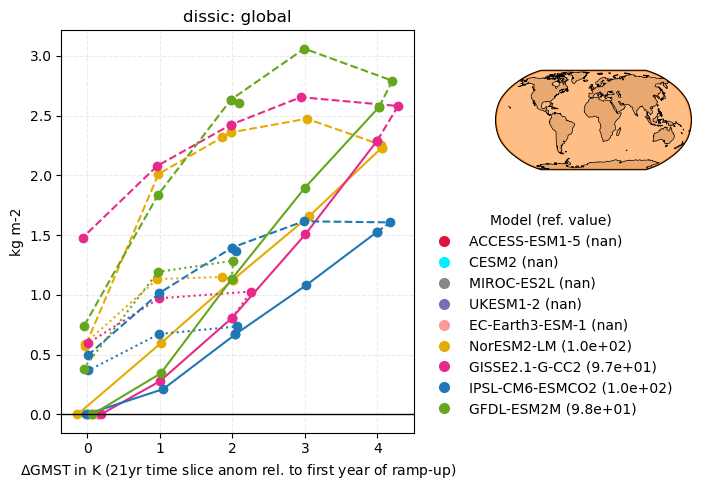

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


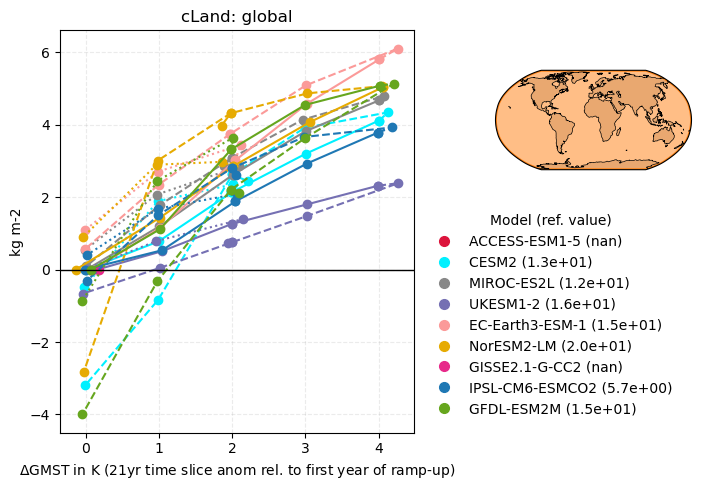

Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some u

/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


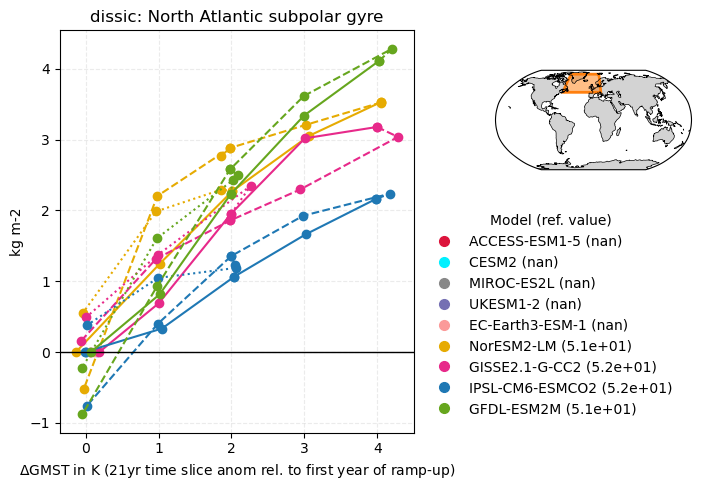

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


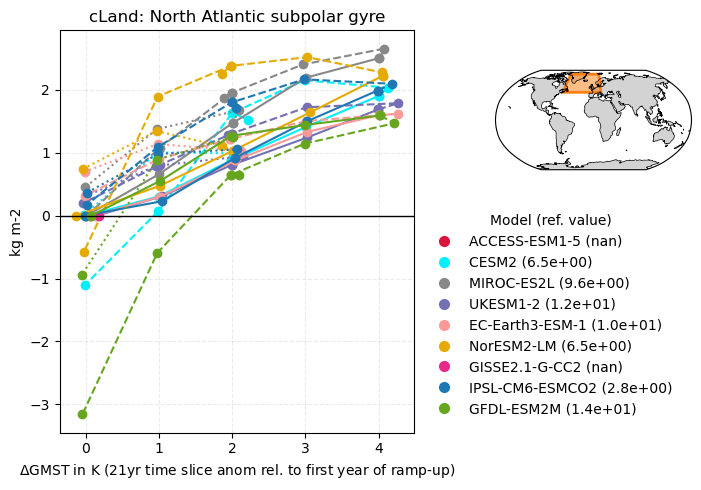

Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some u

/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


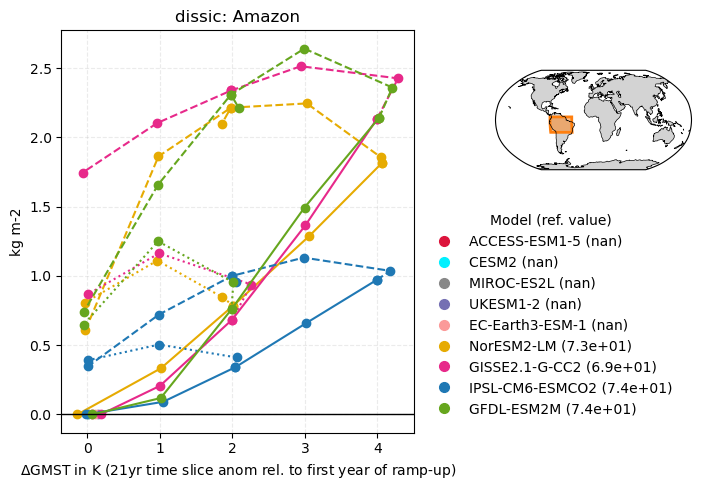

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


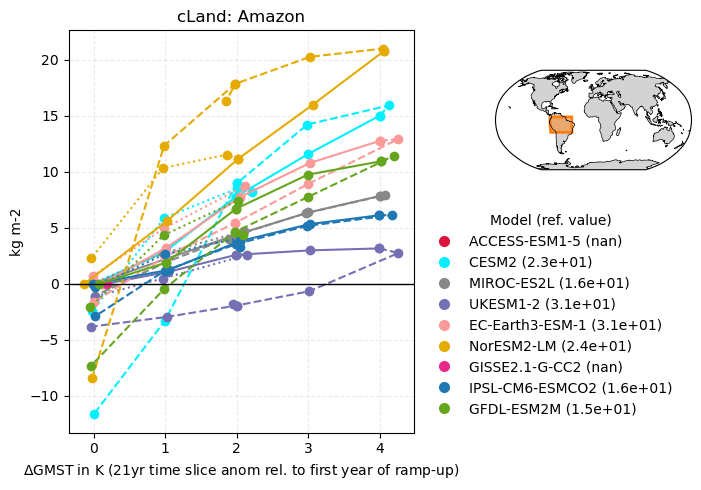

Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some u

/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


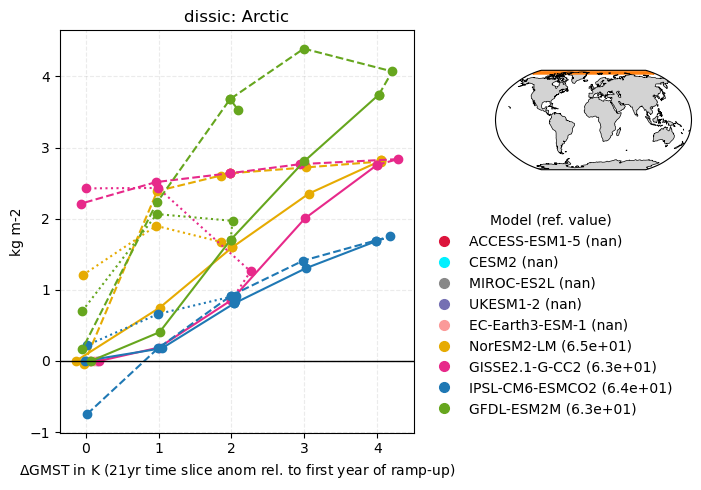

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


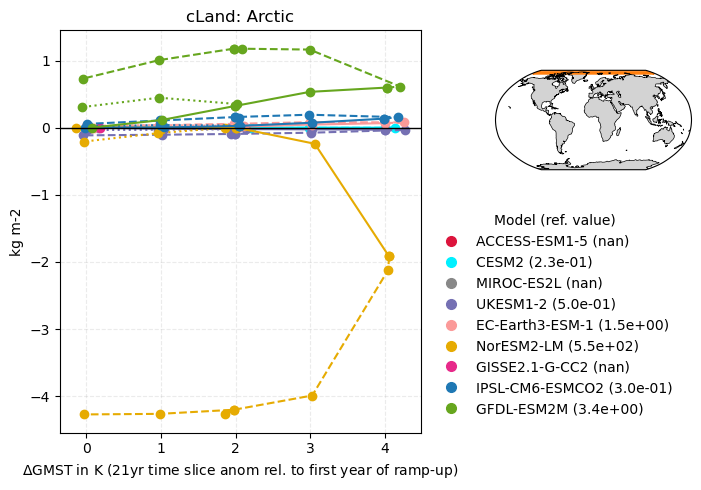

Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some u

/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


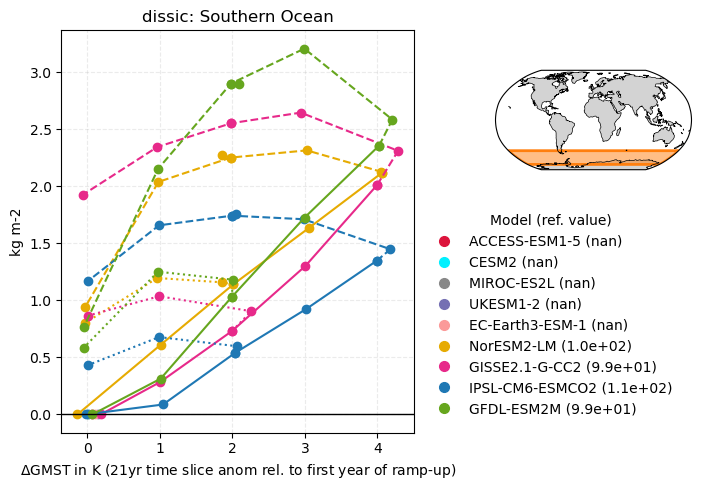

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


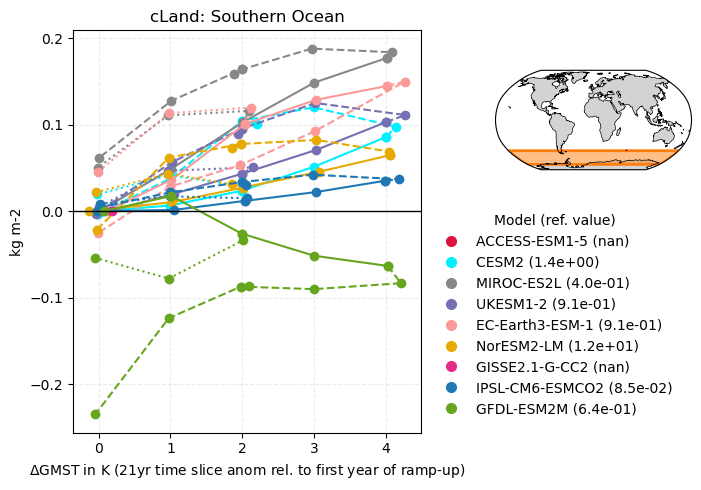

Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: mol m-3 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some unit conversion: kgC/m2 -> kg m-2.
Need to do some u

/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


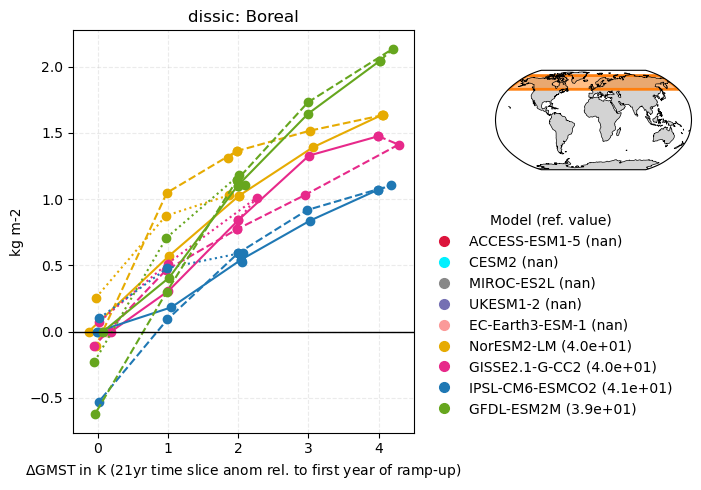

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_1438511/3842489705.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


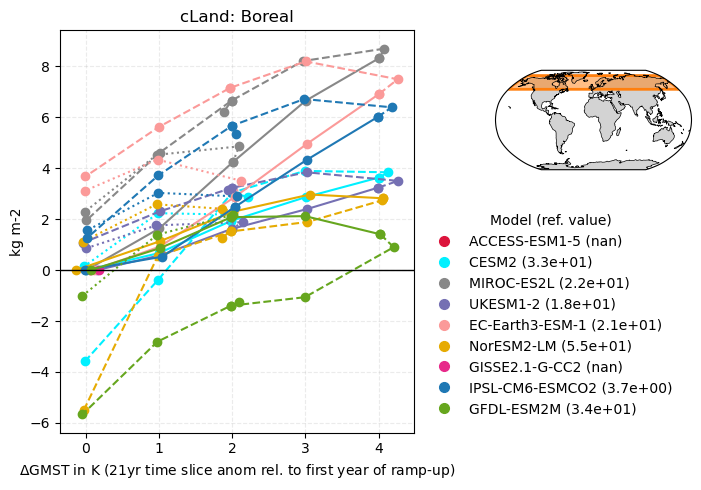

In [100]:
model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

for foc_reg in ['global','North Atlantic subpolar gyre','Amazon','Arctic','Southern Ocean','Boreal']:
    for vdx,varia in enumerate(varias):

        fig, ax = plt.subplots(figsize=(7,5))
        
        cstats, ref_units = get_cstats(varia)
    
        # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
        # use a random file to define the ocean and land and atmosphere mask

        # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
        # use a random file to define the ocean and land and atmosphere mask
        with xr.open_dataset(f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/tos/IPSL-CM6-ESMCO2/ref_first_year_of_rampup_win21yr/mean/tos_IPSL-CM6-ESMCO2_mean_ref_first_year_of_rampup_win21yr.nc') as mask_ds:
            da = mask_ds[f'rampup_1K_{temporal_stat}']
            ocean_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),np.NaN,1)
            land_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),1,np.NaN)
            atmosphere_mask = xr.where(mask_ds.piC_at_start_mean==1e20,np.NaN,1)        
            mask, mask_dict = get_focus_region_mask(foc_reg, da)
            if varia in ['nbp','npp','cLand','cSoil','cVeg']:
                mask_corr = land_mask
            elif varia in ['tos','fgco2','intpp','dissic','intdic']:
                mask_corr = ocean_mask
            elif varia in ['tas']:
                mask_corr = atmosphere_mask
            else:
                raise Exception('Mask not yet implemented for this variable')
            mask = mask*mask_corr
        
        area = get_area(da)

        # merge all the models into one dataset (and make sure that the units are the same)
        all_datasets = []
        for model in models:
            file_path = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
            if os.path.exists(file_path):
                ds = xr.open_dataset(file_path)
            elif varia == 'dissic':
                varia = 'intdic'
                file_path =  f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
                varia = 'dissic'
                if os.path.exists(file_path):
                    ds = xr.open_dataset(file_path)
                else:
                    continue
            else:
                continue
            # add model coordinate
            ds = ds.expand_dims(model=[model])
            # Check if all the units are the same for rampup_1K_mean 
            for ax_name in ax_names:
                if f'{ax_name}_{temporal_stat}' in ds.keys():
                    unit = ds[f'{ax_name}_{temporal_stat}'].unit # ds[f'rampup_1K_{temporal_stat}'].unit
                    if unit not in ref_units:
                        print(f'Need to do some unit conversion: {unit} -> {ref_units[0]}.')
                        if unit == 'mmol/m^3 cm/s' and 'kg m-2 s-1' in ref_units:
                            conv_factor = 12.0107/10**8
                            ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                            ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                            ds.attrs['unit'] = ref_units[0]
                        elif unit == 'gC/m^2/s' and 'kgC/m2/s' in ref_units:
                            conv_factor = 1/1000
                            ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                            ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                            ds.attrs['unit'] = ref_units[0]
                        elif unit == 'gC/m^2' and 'kg m-2' in ref_units:
                            conv_factor = 1/1000
                            ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                            ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                            ds.attrs['unit'] = ref_units[0]
                        elif unit == 'mol m-3' and 'kg m-2' in ref_units:
                            conv_factor = 12.0107/1000. #
                            ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                            ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                            ds.attrs['unit'] = ref_units[0]
                        elif unit == 'kgC/m2' and 'kg m-2' in ref_units:
                            conv_factor = 1. #
                            ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                            ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                            ds.attrs['unit'] = ref_units[0]
                        else:
                            raise ValueError(f"Unit mismatch for {model}, {varia}: {unit} vs reference {ref_units}. Cannot convert.")
            all_datasets.append(ds)        
        ds_all = xr.concat(all_datasets, dim="model", coords='minimal', compat='override')

        ## Do the area weighted averaging in the masked region
        numerator = (ds_all*mask*area).sum(dim=('lat','lon'))
        denominator = (mask*area).sum(dim=('lat','lon'))
        weighted_mean = numerator/denominator
        weighted_mean = xr.where(numerator==0,np.nan,weighted_mean)

        # Now get the global mean temperature anomaly for each slice
        gmst_dum = {}
        for ax_name in ax_names:
            anom_vec = []
            for model in models:
                gmst_anom = get_global_mean_temperature_anomaly(model, ax_name)
                anom_vec.append(gmst_anom)
            gmst_dum[ax_name] = (["model"], anom_vec)
        gmst_anom_ds = xr.Dataset(
            data_vars=gmst_dum,
            coords={"model": models})

        
#
        ref_ys = dict()
        for model in models:
        
            # scatter points
            for ax_name in ax_names:

                tas_global = gmst_anom_ds[ax_name].sel(model=model).values

#                da_dum = weighted_mean[f'{ax_name}_{temporal_stat}']
#                if ax_name == f'piC_at_start_{temporal_stat}':
#                    print('PiC')
#                    if varia in ['fgco2','nbp']:
#                        print('flux')
#                        varia_slice = da_dum.sel(model=model).item()  
#                    else:
#                        varia_slice = 0        
#                else:
#                    print('other')
#                    ref_dum = weighted_mean[f'piC_at_start_{temporal_stat}']
#                    
#                    if model in da_dum.coords['model'].values and model in ref_dum.coords['model'].values:
#                        print('model')
#                        if varia in ['fgco2','nbp']:
#                            print('flux')
#                            varia_slice = da_dum.sel(model=model).item()   
#                        else:
#                            varia_slice = (
#                                da_dum.sel(model=model).item()
#                                - ref_dum.sel(model=model).item()
#                            )
#                    else:
#                        varia_slice = np.nan
                    #varia_slice = (
                    #    da_dum.reindex(model=[model]).values[0]
                    #    - ref_dum.reindex(model=[model]).values[0]
                    #)

                    #tas_global = (
                    #    weighted_mean_global[f'{ax_name}_{temporal_stat}']
                    #    .sel(model=model)
                    #    .values
                    #    - weighted_mean_global[f'piC_at_start_{temporal_stat}']
                    #    .sel(model=model)
                    #    .values
                    #)
        
                #if tas_global != 0 and varia_slice != 0:
                #    ax.scatter(
                #        tas_global,
                #        varia_slice,
                #        20,
                #        model_dict[model].color_id,
                #        zorder=10
                #    )
        
            # line groups
            rampup_names = [
                f'piC_at_start_{temporal_stat}',
                f'rampup_1K_{temporal_stat}',
                f'rampup_2K_{temporal_stat}',
                f'rampup_3K_{temporal_stat}',
                f'rampup_4K_{temporal_stat}'
            ]
        
            rampdn2K_names = [
                f'rampup_2K_{temporal_stat}',
                f'stab2K_{temporal_stat}',
                f'rampdn2K_1K_{temporal_stat}',
                f'rampdn2K_0K_{temporal_stat}'
            ]
        
            rampdn4K_names = [
                f'rampup_4K_{temporal_stat}',
                f'stab4K_{temporal_stat}',
                f'rampdn4K_3K_{temporal_stat}',
                f'rampdn4K_2K_{temporal_stat}',
                f'rampdn4K_1K_{temporal_stat}',
                f'rampdn4K_0K_{temporal_stat}'
            ]
        
            restab2K_names = [
                f'rampdn4K_2K_{temporal_stat}',
                f'restab2K_{temporal_stat}'
            ]
        
            rampup_x, rampup_y, ref_y = collect_series(
                rampup_names,
                model,
                weighted_mean,
                gmst_anom_ds,
                temporal_stat,
                varia
            )
        
            rampdn2K_x, rampdn2K_y, ref_y = collect_series(
                rampdn2K_names,
                model,
                weighted_mean,
                gmst_anom_ds,
                temporal_stat,
                varia
            )
        
            rampdn4K_x, rampdn4K_y, ref_y = collect_series(
                rampdn4K_names,
                model,
                weighted_mean,
                gmst_anom_ds,
                temporal_stat,
                varia
            )
        
            restab2K_x, restab2K_y, ref_y = collect_series(
                restab2K_names,
                model,
                weighted_mean,
                gmst_anom_ds,
                temporal_stat,
                varia
            )

            ref_ys[model] = ref_y
        
            # plot lines
            color = model_dict[model].color_id
        
            ax.plot(rampup_x, rampup_y, color=color,marker='o')
            ax.plot(rampdn2K_x, rampdn2K_y, color=color, linestyle=':',marker='o')
            ax.plot(rampdn4K_x, rampdn4K_y, color=color, linestyle='--',marker='o')
            ax.plot(restab2K_x, restab2K_y, color=color, linestyle='-.',marker='o')

        ax.set_title(f'{varia}: {foc_reg}')
        ax.set_xlabel(r'$\Delta$GMST in K (21yr time slice anom rel. to first year of ramp-up)')
        ax.set_ylabel(ref_units[0])
        ax.grid(alpha=0.25,linestyle='--')
        ax.axhline(0,color='k',linewidth=1)

        # create legend handles
        if varia in ['tas','tos']:
            legend_handles = [
                Line2D(
                    [0],
                    [0],
                    marker='o',
                    color='none',
                    markerfacecolor=model_dict[model].color_id,
                    markeredgecolor=model_dict[model].color_id,
                    markersize=7,
                    label=f'{model} ({ref_ys[model]:.1f})'
                )
                for model in models
            ]
        else:
            legend_handles = [
                Line2D(
                    [0],
                    [0],
                    marker='o',
                    color='none',
                    markerfacecolor=model_dict[model].color_id,
                    markeredgecolor=model_dict[model].color_id,
                    markersize=7,
                    label=f'{model} ({ref_ys[model]:.1e})'
                )
                for model in models
            ]            
        
        ax.legend(
            handles=legend_handles,
            title='Model (ref. value)',
            loc='lower left',
            frameon=False,
            bbox_to_anchor=(1.01,0.01)
        )

        # add inset axis in the top-right of the figure
        ax_map = fig.add_axes([0.715, 0.6, 0.28, 0.3], projection=ccrs.Robinson())
        ax_map.set_global()
        ax_map.add_feature(cfeature.LAND, facecolor="lightgray")
        ax_map.add_feature(cfeature.OCEAN, facecolor="white")
        ax_map.coastlines(linewidth=0.5)
    
        rect = mpatches.Rectangle(
            (mask_dict['lon_min'], mask_dict['lat_min']),
            mask_dict['lon_max'] - mask_dict['lon_min'],
            mask_dict['lat_max'] - mask_dict['lat_min'],
            linewidth=2,
            edgecolor="C1",
            facecolor="#ff7f0e80",
            transform=ccrs.PlateCarree()
        )
        
        ax_map.add_patch(rect)

        plt.tight_layout()
        plot_dir = f'./../03_plots/global_time_slice_maps_line_plots/{varia}/ref_first_year_of_rampup_win_21yr/{temporal_stat}/'
        os.makedirs(plot_dir,exist_ok=True)
        plot_filename =f"{varia}_MMM_{temporal_stat}_ref_first_year_of_rampup_win21yr_{foc_reg.replace(' ','_')}.png"
        fig.savefig(f'{plot_dir}/{plot_filename}',transparent=True,dpi=200)
        plt.show()
